# ML-Enhanced Player Recruitment Tool
### Phase 2: Vacancy Fit & Value Intelligence

**Two ML models integrated with the scouting pipeline:**

| Model | Question it answers | Method |
|-------|-------------------|--------|
| **1. Team Fit** | "Does this player's style match our club?" | Cosine similarity to club profile + per-role comparison |
| **2. Value Intelligence** | "Is this player undervalued for their ability?" | XGBoost regression: predict market value from performance → find residuals |

Both scores are combined into a **composite recruitment score** with minutes-based reliability weighting.

**Data:** Celtic FC practical task dataset (7692 rows, 108 metrics, per-90 normalised)


## 1) Setup & Configuration

In [1]:
import re
import copy
import warnings
import inspect
from pathlib import Path
from dataclasses import dataclass, field
from typing import Optional, Dict, List, Set, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch

from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_predict, KFold, GroupKFold
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Optional: UMAP for better clustering visualisation
try:
    from umap import UMAP
    HAS_UMAP = True
except ImportError:
    from sklearn.decomposition import PCA
    HAS_UMAP = False
    print("UMAP not installed — falling back to PCA. Install with: pip install umap-learn")

# Optional: SHAP for model explainability
try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False
    print("SHAP not installed — skipping SHAP diagnostics.")

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

print("Setup complete.")



Bad key "text.kerning_factor" on line 4 in
/Applications/anaconda3/lib/python3.7/site-packages/matplotlib/mpl-data/stylelib/_classic_test_patch.mplstyle.
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.1.3/matplotlibrc.template
or from the matplotlib source distribution


UMAP not installed — falling back to PCA. Install with: pip install umap-learn
SHAP not installed — skipping SHAP diagnostics.
Setup complete.


## 2) Configuration

Edit `MY_CLUB` and filters to adapt for any club/dataset.


In [2]:
# === EDIT HERE ===
DATA_PATH = "data/Final_Task_Data.csv"
MY_CLUB = "Celtic"
EXCLUDE_TEAMS = [MY_CLUB]  # club-agnostic default; set [] to keep the current club in view

# Optional season anchor for the current squad profile.
# Leave as None to resolve automatically to the latest season available for MY_CLUB.
TARGET_SEASON = None

# Minimum minutes threshold.
# Set to 450 as a baseline: per-90 metrics are unreliable below ~5 full matches.
# This avoids noise from very low-sample players dominating z-score rankings.
MIN_MINUTES = 450.0

# For readability in the final ranking table, keep only the latest/best row per player
# after scoring. The model itself still scores player-team-season rows.
ONE_ROW_PER_PLAYER_IN_RANKING = True

AGE_MAX = 30
BUDGET_MAX_EUR = 10_000_000
N_SHORTLIST = 4

# Optional target-market definition for league context.
# If None, the notebook uses MY_CLUB's own league(s) as the target market.
TARGET_LEAGUES = None

# Optional manual side preference for a specific scouting task.
# Use one of: None, "Left", "Right", "Centre"
# Leave as None for a general portfolio ranking.
TARGET_SIDE = None

# Role-board mapping keeps comparisons role-specific in the visible outputs.
# The notebook still computes a common underlying score, but the main tables and
# shortlist assembly operate through role boards instead of a single mixed-position ranking.
ROLE_BOARD_MAP = {
    "CB": "CB", "RCB": "CB", "LCB": "CB",
    "RFB": "Right FB/WB", "RWB": "Right FB/WB",
    "LFB": "Left FB/WB", "LWB": "Left FB/WB",
    "DMF": "DMF", "CMF": "CMF", "AMF": "AMF",
    "RW": "Right Wide", "RM": "Right Wide",
    "LW": "Left Wide", "LM": "Left Wide",
    "CF": "CF",
}

# Boards that the shortlist should cover first.
# This keeps the final portfolio role-aware instead of relying on a single cross-position ranking.
SHORTLIST_BOARD_TARGETS = {
    "CB": {"CB"},
    "Right FB/WB": {"Right FB/WB"},
    "Front line": {"CF", "Right Wide", "Left Wide", "AMF"},
}
MAX_PER_BOARD = 1

# IMPORTANT:
# This notebook does NOT apply a hard cross-league performance conversion factor.
# Instead, it handles league context conservatively through a translation-risk layer.
# Reason:
# - the dataset does not contain transfer-linked player movement data
# - it therefore cannot support a validated league-to-league exchange-rate model
#
# Practical implication:
# - player performance metrics are standardised within the dataset as before
# - league context is only used to flag how cautious we should be when reading
#   performance from one competition against a target market in another

# Relative weights for the final shortlist score.
# VFM has been removed from the ranking to avoid double-counting performance.
W_VACANCY = 0.70
W_VALUE_IQ = 0.30

# Internal split for vacancy fit
W_FUNCTIONAL = 0.60
W_COMPLEMENTARITY = 0.40

# Minutes-based reliability dampening.
# Players with fewer minutes get their final score scaled down.
# full_reliability_minutes: above this threshold, weight = 1.0
FULL_RELIABILITY_MINUTES = 1800.0
MIN_RELIABILITY_WEIGHT = 0.3


print(f"Club: {MY_CLUB} | Budget: €{BUDGET_MAX_EUR:,.0f} | Shortlist: {N_SHORTLIST}")
print(f"Target season override: {TARGET_SEASON}")
print(f"Minimum minutes threshold for market pool: {MIN_MINUTES}")
print(f"Latest/best row per player in ranking table: {ONE_ROW_PER_PLAYER_IN_RANKING}")
print(f"Relative weights → Vacancy: {W_VACANCY} | Value IQ: {W_VALUE_IQ}")
print(f"Reliability dampening → full at {FULL_RELIABILITY_MINUTES} min, floor {MIN_RELIABILITY_WEIGHT}")
print(f"Vacancy split → Functional: {W_FUNCTIONAL} | Complementarity: {W_COMPLEMENTARITY}")
print(f"Target leagues override: {TARGET_LEAGUES}")
print(f"Target side override: {TARGET_SIDE}")
print("League context mode: risk-only (no hard cross-league conversion factor)")
# Style clustering removed from this version (was diagnostic-only with no scoring impact).

# Lightweight correlation-pruning settings for role metrics
# Purpose:
# - reduce obvious duplicate signals inside each role-specific metric set
# - keep the notebook interpretable without introducing PCA or black-box compression
ENABLE_LIGHT_CORR_PRUNING = True
CORR_PRUNE_THRESHOLD = 0.85
MIN_CORR_SAMPLE = 25

print(f"Light correlation pruning: {ENABLE_LIGHT_CORR_PRUNING} | threshold: {CORR_PRUNE_THRESHOLD} | min sample: {MIN_CORR_SAMPLE}")


Club: Celtic | Budget: €10,000,000 | Shortlist: 4
Target season override: None
Minimum minutes threshold for market pool: 450.0
Latest/best row per player in ranking table: True
Relative weights → Vacancy: 0.7 | Value IQ: 0.3
Reliability dampening → full at 1800.0 min, floor 0.3
Vacancy split → Functional: 0.6 | Complementarity: 0.4
Target leagues override: None
Target side override: None
League context mode: risk-only (no hard cross-league conversion factor)
Light correlation pruning: True | threshold: 0.85 | min sample: 25


## 3) Load & Prepare Data

In [3]:
def parse_value(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s in {"?", "nan", "none", ""}:
        return np.nan
    s = s.replace(",", "")
    m = re.fullmatch(r"(\d+\.?\d*)([km])?", s)
    if m:
        num = float(m.group(1))
        unit = m.group(2)
        if unit == "k":
            return num * 1_000
        elif unit == "m":
            return num * 1_000_000
        return num
    m2 = re.search(r"(\d+\.?\d*)", s)
    return float(m2.group(1)) if m2 else np.nan

def to_bucket(pos):
    if pd.isna(pos):
        return "Unknown"
    p = str(pos).strip()
    mapping = {
        "Goalkeeper": "GK",
        "Right Centre Back": "RCB", "Left Centre Back": "LCB",
        "Right Back": "RFB", "Left Back": "LFB",
        "Right Wing Back": "RWB", "Left Wing Back": "LWB",
        "Centre Defensive Midfielder": "DMF", "Right Defensive Midfielder": "DMF",
        "Left Defensive Midfielder": "DMF",
        "Left Midfielder": "LM", "Right Midfielder": "RM",
        "Left Wing": "LW", "Right Winger": "RW", "Right Wingerer": "RW",
        "Right Wingerer Back": "RWB", "Right Wing Back": "RWB",
    }
    if p in mapping:
        return mapping[p]
    if "Centre Back" in p or "Center Back" in p:
        return "CB"
    if "Centre Midfielder" in p or "Central Midfielder" in p:
        return "CMF"
    if "Attacking Midfielder" in p:
        return "AMF"
    if "Forward" in p:
        return "CF"
    return "Unknown"

SIDE_DEFAULT_BY_BUCKET = {
    "RCB": "Right", "LCB": "Left", "RFB": "Right", "LFB": "Left",
    "RWB": "Right", "LWB": "Left", "RW": "Right", "LW": "Left",
    "RM": "Right", "LM": "Left", "CB": "Centre", "CMF": "Centre",
    "DMF": "Centre", "AMF": "Centre", "CF": "Centre", "GK": "Centre"
}

SIDE_SENSITIVE_BUCKETS = {"RCB", "LCB", "RFB", "LFB", "RWB", "LWB", "RW", "LW", "RM", "LM"}

def infer_side_from_position(pos):
    if pd.isna(pos):
        return np.nan
    p = str(pos).strip().lower()
    if "left" in p:
        return "Left"
    if "right" in p:
        return "Right"
    if "centre" in p or "center" in p or "central" in p:
        return "Centre"
    return np.nan

def resolve_player_side(bucket, pos1=None, pos2=None):
    bucket_side = SIDE_DEFAULT_BY_BUCKET.get(bucket)
    if bucket_side in {"Left", "Right", "Centre"}:
        return bucket_side
    for pos in [pos1, pos2]:
        side = infer_side_from_position(pos)
        if side in {"Left", "Right", "Centre"}:
            return side
    return "Unknown"

def is_side_specific_bucket(bucket):
    return bucket in SIDE_SENSITIVE_BUCKETS

def minmax_01(series):
    s = pd.to_numeric(series, errors="coerce")
    valid = s.dropna()
    if len(valid) == 0:
        return pd.Series(np.nan, index=s.index)
    lo, hi = valid.min(), valid.max()
    if hi - lo < 1e-9:
        return pd.Series(0.0, index=s.index)
    return (s - lo) / (hi - lo)

def risk_label(x):
    if pd.isna(x):
        return "Unknown"
    if x < 0.33:
        return "Low"
    elif x < 0.66:
        return "Medium"
    return "High"

def season_sort_key(season_value):
    """
    Convert season labels such as '2023/2024', '2023-24', '23/24', or '2024'
    into a sortable numeric key. Higher = more recent.
    """
    if pd.isna(season_value):
        return -1
    s = str(season_value).strip()
    nums = re.findall(r"\d{2,4}", s)
    if not nums:
        return -1

    norm = []
    for token in nums:
        n = int(token)
        if len(token) == 2:
            n = 2000 + n if n < 40 else 1900 + n
        norm.append(n)

    return max(norm) if norm else -1

# Load
raw = pd.read_csv(DATA_PATH)
print(f"Loaded: {raw.shape[0]} rows × {raw.shape[1]} columns")

# Parse / normalise
raw["Value_EUR"] = raw["Value"].apply(parse_value)
raw["pos_bucket"] = raw["Position_1"].apply(to_bucket)
raw["Team_clean"] = raw["Team"].astype(str).str.strip()
raw["League_clean"] = raw["League"].astype(str).str.strip()
raw["Season_clean"] = raw["Season"].astype(str).str.strip()
raw["Season_sort_key"] = raw["Season_clean"].apply(season_sort_key)

raw["Age"] = pd.to_numeric(raw["Age"], errors="coerce")
raw["Minutes"] = pd.to_numeric(raw["Minutes"], errors="coerce")

raw["record_key"] = (
    raw["ID"].astype(str)
    + "__" + raw["Team_clean"].astype(str)
    + "__" + raw["Season_clean"].astype(str)
)

raw["primary_side"] = raw.apply(
    lambda r: resolve_player_side(r["pos_bucket"], r.get("Position_1"), r.get("Position_2")),
    axis=1
)
raw["secondary_side"] = raw["Position_2"].apply(infer_side_from_position)
raw["is_side_specific_role"] = raw["pos_bucket"].apply(is_side_specific_bucket)

# IMPORTANT:
# Keep player-team-season rows intact. The previous ID-level collapse was removed
# because it conflicted with league-season context and could silently drop the
# most relevant season.
print(f"Working rows retained (no ID-level deduplication): {len(raw)}")
dup_players = int(raw["ID"].duplicated().sum())
print(f"Rows sharing an ID across seasons/teams: {dup_players}")

# Resolve the squad-profiling season for MY_CLUB.
club_rows_all = raw[raw["Team_clean"].str.contains(MY_CLUB, case=False, na=False)].copy()
if len(club_rows_all):
    if TARGET_SEASON is not None:
        CLUB_PROFILE_SEASON = str(TARGET_SEASON)
    else:
        latest_key = club_rows_all["Season_sort_key"].max()
        latest_seasons = club_rows_all.loc[club_rows_all["Season_sort_key"].eq(latest_key), "Season_clean"].dropna().unique().tolist()
        CLUB_PROFILE_SEASON = sorted(latest_seasons)[-1] if latest_seasons else None
else:
    CLUB_PROFILE_SEASON = TARGET_SEASON

if CLUB_PROFILE_SEASON is not None:
    my_club_df = club_rows_all[club_rows_all["Season_clean"].eq(CLUB_PROFILE_SEASON)].copy()
else:
    my_club_df = club_rows_all.copy()

print(f"{MY_CLUB} squad profile season: {CLUB_PROFILE_SEASON}")
print(f"{MY_CLUB} squad rows used for complementarity: {len(my_club_df)}")
if len(my_club_df):
    print(f"  Positions: {my_club_df['pos_bucket'].value_counts().to_dict()}")
    print(f"  Side tags: {my_club_df['primary_side'].value_counts(dropna=False).to_dict()}")

# Resolve target market for league-context analysis.
club_leagues = sorted(x for x in my_club_df["League_clean"].dropna().unique().tolist() if x and x != "nan")
TARGET_LEAGUES_RESOLVED = TARGET_LEAGUES if TARGET_LEAGUES else club_leagues

if not TARGET_LEAGUES_RESOLVED:
    TARGET_LEAGUES_RESOLVED = sorted(x for x in raw["League_clean"].dropna().unique().tolist() if x and x != "nan")

print(f"Target leagues used for league-context analysis: {TARGET_LEAGUES_RESOLVED}")

# Build a conservative empirical league-season context proxy from the current dataset.
# This is NOT treated as a hard league-to-league performance conversion factor.
league_base = raw[raw["Value_EUR"].notna() & (raw["Value_EUR"] > 0)].copy()
league_base["log_value"] = np.log1p(league_base["Value_EUR"])

league_strength = (
    league_base.groupby(["League_clean", "Season_clean"], as_index=False)
    .agg(
        league_strength=("log_value", "median"),
        league_strength_n=("ID", "count")
    )
)

target_strength_by_season = (
    league_strength[league_strength["League_clean"].isin(TARGET_LEAGUES_RESOLVED)]
    .groupby("Season_clean")["league_strength"]
    .median()
)

overall_target_strength = (
    league_strength.loc[league_strength["League_clean"].isin(TARGET_LEAGUES_RESOLVED), "league_strength"]
    .median()
)

raw = raw.merge(league_strength, on=["League_clean", "Season_clean"], how="left")
raw["target_market_strength"] = raw["Season_clean"].map(target_strength_by_season)

if pd.notna(overall_target_strength):
    raw["target_market_strength"] = raw["target_market_strength"].fillna(overall_target_strength)

raw["league_strength_source"] = "empirical_league_season_proxy"

# Directional gap: upward move into a stronger target market is treated as translation risk.
# Moves from stronger or equivalent leagues are not forced into a penalty.
raw["league_translation_gap_raw"] = (
    raw["target_market_strength"] - raw["league_strength"]
).clip(lower=0)

print("\nLeague-strength proxy built.")
display(
    raw[[
        "record_key", "ID", "Team_clean", "League_clean", "Season_clean",
        "league_strength", "target_market_strength",
        "league_translation_gap_raw", "league_strength_source"
    ]].head(10)
)


Loaded: 7692 rows × 108 columns
Working rows retained (no ID-level deduplication): 7692
Rows sharing an ID across seasons/teams: 737
Celtic squad profile season: 2024/2025
Celtic squad rows used for complementarity: 32
  Positions: {'Unknown': 5, 'CMF': 5, 'CF': 3, 'RW': 3, 'RCB': 3, 'LFB': 3, 'LW': 3, 'LCB': 2, 'RFB': 2, 'GK': 2, 'DMF': 1}
  Side tags: {'Centre': 11, 'Left': 8, 'Right': 8, 'Unknown': 5}
Target leagues used for league-context analysis: ['Premiership']

League-strength proxy built.


,record_key,ID,Team_clean,League_clean,Season_clean,league_strength,target_market_strength,league_translation_gap_raw,league_strength_source
0,47196__Haugesund__2025,47196,Haugesund,Eliteserien,2025,13.17002,13.017005,0.0,empirical_league_season_proxy
1,75938__Molde__2025,75938,Molde,Eliteserien,2025,13.17002,13.017005,0.0,empirical_league_season_proxy
2,18605__Bodo / Glimt__2025,18605,Bodo / Glimt,Eliteserien,2025,13.17002,13.017005,0.0,empirical_league_season_proxy
3,67388__Rosenborg BK__2025,67388,Rosenborg BK,Eliteserien,2025,13.17002,13.017005,0.0,empirical_league_season_proxy
4,91297__Sandefjord__2025,91297,Sandefjord,Eliteserien,2025,13.17002,13.017005,0.0,empirical_league_season_proxy
5,65501__Kristiansund__2025,65501,Kristiansund,Eliteserien,2025,13.17002,13.017005,0.0,empirical_league_season_proxy
6,63309__Kristiansund__2025,63309,Kristiansund,Eliteserien,2025,13.17002,13.017005,0.0,empirical_league_season_proxy
7,37043__Viking__2025,37043,Viking,Eliteserien,2025,13.17002,13.017005,0.0,empirical_league_season_proxy
8,43635__Haugesund__2025,43635,Haugesund,Eliteserien,2025,13.17002,13.017005,0.0,empirical_league_season_proxy
9,89315__Bryne__2025,89315,Bryne,Eliteserien,2025,13.17002,13.017005,0.0,empirical_league_season_proxy


## 4) Define Feature Sets per Role

These are all the per-90 metrics available in the dataset, grouped by relevance to each position.


In [4]:
# Metrics usable for ML (all per-90, exclude GK-specific for outfield)
OUTFIELD_METRICS = [
    "Np_xg", "Np_xg_per_shot", "Np_shots", "Goals", "Np_goals",
    "Xa", "Key_passes", "Op_key_passes", "Assists", "Through_balls",
    "Passes_into_box", "Op_passes_into_box", "Touches_in_box",
    "Tackles", "Interceptions", "Padj_tackles", "Padj_interceptions",
    "Dribbles_successful", "Dribbled_past", "Fouls", "Dispossessed",
    "Long_ball_percentage", "Long_balls", "Block_per_shot", "Clearance",
    "Aerial_percentage", "Aerial_won", "Op_passes",
    "Forward_pass_proportion", "Backward_pass_proportion",
    "Op_last_3rd_passes", "Shot_target_percentage", "Passing_percentage",
    "Goal_conversion", "Crosses_completed", "Crossing_percentage",
    "Xgchain", "Op_xgchain", "Xgbuildup", "Op_xgbuildup",
    "Xgchain_per_possession", "Op_xgchain_per_possession",
    "Xgbuildup_per_possession", "Op_xgbuildup_per_possession",
    "Pressures", "Successful_pressures", "Padj_pressures",
    "Pass_and_carry_last_3rd", "Fouls_won",
    "Failed_dribbles", "Dribbles_percentage",
    "Carries", "Successful_carries_percentage", "Carry_length",
    "Counterpressures", "Successful_counterpressures",
    "Ball_recoveries", "Defensive_actions",
    "Pressing_distance", "Opp_half_pressures",
    "Passing_percentage_under_pressure", "Attempted_pass_length",
    "Shot_per_touch", "Errors",
    "Last_3rd_forward_pass_proportion",
    "Padj_Clearances",
]

# Role-specific metric subsets (for team fit comparison)
ROLE_METRICS = {
    "CB":  ["Aerial_won", "Aerial_percentage", "Interceptions", "Tackles", "Padj_tackles",
            "Padj_interceptions", "Block_per_shot", "Clearance", "Padj_Clearances",
            "Passing_percentage", "Long_ball_percentage", "Long_balls",
            "Ball_recoveries", "Pressures", "Dribbled_past", "Errors",
            "Passing_percentage_under_pressure", "Attempted_pass_length"],
    "RCB": None,  # falls back to CB
    "LCB": None,
    "FB":  ["Tackles", "Interceptions", "Padj_pressures", "Successful_pressures",
            "Crosses_completed", "Crossing_percentage", "Carries",
            "Pass_and_carry_last_3rd", "Dribbles_successful", "Ball_recoveries",
            "Xgbuildup", "Op_passes", "Pressing_distance"],
    "RFB": None, "LFB": None,
    "DMF": ["Padj_tackles", "Padj_interceptions", "Successful_pressures", "Ball_recoveries",
            "Passing_percentage", "Op_passes", "Long_balls", "Pressures", "Errors",
            "Passing_percentage_under_pressure", "Carries", "Xgbuildup"],
    "CMF": ["Op_passes", "Pass_and_carry_last_3rd", "Pressures",
            "Ball_recoveries", "Passing_percentage", "Interceptions", "Tackles",
            "Xgbuildup", "Xgchain", "Key_passes", "Carries", "Errors"],
    "AMF": ["Xa", "Key_passes", "Through_balls", "Passes_into_box", "Np_xg",
            "Xgchain", "Carries", "Shot_target_percentage", "Dispossessed",
            "Dribbles_successful", "Op_xgchain_per_possession"],
    "W":   ["Np_xg", "Xa", "Shot_target_percentage", "Goal_conversion",
            "Dribbles_successful", "Carries", "Carry_length",
            "Crosses_completed", "Crossing_percentage", "Key_passes",
            "Dispossessed", "Xgchain", "Touches_in_box"],
    "LW": None, "RW": None, "LM": None, "RM": None,
    "CF":  ["Np_xg", "Goals", "Np_goals", "Shot_target_percentage", "Goal_conversion",
            "Touches_in_box", "Xgchain", "Xa", "Key_passes", "Dispossessed",
            "Aerial_won", "Pressures", "Np_xg_per_shot"],
}

# Resolve fallbacks
BUCKET_FAMILY = {
    "RCB": "CB", "LCB": "CB",
    "RFB": "FB", "LFB": "FB", "RWB": "FB", "LWB": "FB",
    "LW": "W", "RW": "W", "LM": "W", "RM": "W",
}

def get_role_metrics(bucket):
    source_map = ACTIVE_ROLE_METRICS if "ACTIVE_ROLE_METRICS" in globals() else ROLE_METRICS
    if source_map.get(bucket) is not None:
        return source_map[bucket]
    family = BUCKET_FAMILY.get(bucket, bucket)
    return source_map.get(family, OUTFIELD_METRICS[:20])

def lightweight_corr_prune_by_role(market_df, role_metrics, threshold=0.85, min_sample=25):
    """
    Greedy, interpretable correlation pruning inside each role-metric set.

    Design choice:
    - work within role families, not globally
    - use absolute Spearman correlation
    - keep the earlier metric in each role list when two metrics are very similar
      because the list order reflects domain preference / interpretability
    - produce an audit table so the pruning is transparent rather than hidden
    """
    active = {k: (list(v) if isinstance(v, list) else None) for k, v in role_metrics.items()}
    audit_rows = []

    for role_key, metrics in role_metrics.items():
        if not isinstance(metrics, list) or len(metrics) < 2:
            continue

        family = BUCKET_FAMILY.get(role_key, role_key)
        role_pool = market_df[market_df["role_family"].eq(family)].copy()
        present = [m for m in metrics if m in role_pool.columns]
        present = list(dict.fromkeys(present))

        if len(present) < 2 or len(role_pool) < min_sample:
            for m in present:
                audit_rows.append({
                    "role_key": role_key,
                    "role_family": family,
                    "kept_metric": m,
                    "dropped_metric": None,
                    "abs_spearman_corr": np.nan,
                    "decision": "kept_no_pruning",
                    "reason": "insufficient role-specific sample or too few available metrics"
                })
            active[role_key] = present
            continue

        role_numeric = role_pool[present].apply(pd.to_numeric, errors="coerce")
        corr = role_numeric.corr(method="spearman", min_periods=min_sample).abs()

        keep = []
        dropped = set()

        for i, metric in enumerate(present):
            if metric in dropped:
                continue
            keep.append(metric)
            audit_rows.append({
                "role_key": role_key,
                "role_family": family,
                "kept_metric": metric,
                "dropped_metric": None,
                "abs_spearman_corr": np.nan,
                "decision": "kept",
                "reason": "earlier metric retained as representative signal"
            })

            for other in present[i+1:]:
                if other in dropped:
                    continue
                corr_val = corr.loc[metric, other] if metric in corr.index and other in corr.columns else np.nan
                if pd.notna(corr_val) and corr_val >= threshold:
                    dropped.add(other)
                    audit_rows.append({
                        "role_key": role_key,
                        "role_family": family,
                        "kept_metric": metric,
                        "dropped_metric": other,
                        "abs_spearman_corr": float(corr_val),
                        "decision": "dropped_high_correlation",
                        "reason": f"absolute Spearman correlation >= {threshold}"
                    })

        active[role_key] = keep

    audit_df = pd.DataFrame(audit_rows)
    return active, audit_df

print("Role metrics defined for:", [k for k, v in ROLE_METRICS.items() if v is not None])


Role metrics defined for: ['CB', 'FB', 'DMF', 'CMF', 'AMF', 'W', 'CF']


## 4b) Lightweight Correlation Pruning Within Role Metric Sets

This notebook keeps the role profiles interpretable, so it does **not** use PCA or latent-factor compression.

Instead, it applies a **lightweight, role-aware correlation audit**:

- correlations are checked **within each role family**
- only **very highly correlated** metric pairs are pruned
- the earlier metric in each role list is retained as the representative signal
- every keep/drop decision is written to an audit table

This is designed to reduce obvious double-counting while keeping the metric definitions readable for scouting communication.


## 5) MODEL 1: Vacancy Fit  
### Functional Fit + Squad Complementarity

This section replaces the earlier **team-similarity fit** idea.

The model now separates three practical questions:

1. **Functional Fit**  
   How well does the candidate match the role profile implied by their position-specific metrics?

2. **Squad Complementarity**  
   How much does the candidate improve the current squad where the club looks below a market benchmark for that role?

3. **Side Context**  
   For wide or side-specific roles, are we comparing the player against the correct left/right reference group?

In this notebook, side information is handled conservatively:

- it is derived from the position labels already present in the dataset
- it makes the **complementarity comparison** more specific for left/right roles
- it does **not** claim to know the player's preferred foot or true in-possession lane occupation

The final **Vacancy Fit** score remains:

```python
Vacancy Fit = W_FUNCTIONAL × Functional Fit + W_COMPLEMENTARITY × Squad Complementarity
```

This is a more recruitment-oriented interpretation of fit than simply asking whether a player looks similar to the current squad average.

In [5]:
ROLE_EQUIV = {
    "RCB": {"RCB", "LCB", "CB"}, "LCB": {"RCB", "LCB", "CB"}, "CB": {"RCB", "LCB", "CB"},
    "RFB": {"RFB", "LFB", "RWB", "LWB"}, "LFB": {"RFB", "LFB", "RWB", "LWB"},
    "RWB": {"RFB", "LFB", "RWB", "LWB"}, "LWB": {"RFB", "LFB", "RWB", "LWB"},
    "LW": {"LW", "RW", "LM", "RM"}, "RW": {"LW", "RW", "LM", "RM"},
    "LM": {"LW", "RW", "LM", "RM"}, "RM": {"LW", "RW", "LM", "RM"},
    "CF": {"CF"}, "AMF": {"AMF"}, "DMF": {"DMF"}, "CMF": {"CMF"},
}

LOWER_IS_BETTER_LOCAL = {"Errors", "Dribbled_past", "Dispossessed", "Fouls", "Failed_dribbles", "Turnovers"}

def zscore_group(x, g):
    x = pd.to_numeric(x, errors="coerce")
    mu = x.groupby(g).transform("mean")
    sd = x.groupby(g).transform("std").replace(0, np.nan)
    return (x - mu) / sd

def minmax_group(series, groups):
    s = pd.to_numeric(series, errors="coerce")
    lo = s.groupby(groups).transform("min")
    hi = s.groupby(groups).transform("max")
    return ((s - lo) / (hi - lo + 1e-9)).clip(0, 1)

def resolve_role_family(bucket):
    return BUCKET_FAMILY.get(bucket, bucket)


def assign_role_board(bucket):
    return ROLE_BOARD_MAP.get(bucket, bucket if pd.notna(bucket) else "Unknown")

def minutes_evidence_label(minutes):
    if pd.isna(minutes):
        return "Unknown"
    if minutes >= 1800:
        return "High"
    if minutes >= 900:
        return "Medium"
    return "Low"

MINUTES_EVIDENCE_SORT_MAP = {"High": 2, "Medium": 1, "Low": 0, "Unknown": -1}

def side_aware_equiv_buckets(bucket, player_side):
    family = resolve_role_family(bucket)

    if family == "FB":
        if player_side == "Left":
            return {"LFB", "LWB"}
        if player_side == "Right":
            return {"RFB", "RWB"}
        return {"RFB", "LFB", "RWB", "LWB"}

    if family == "W":
        if player_side == "Left":
            return {"LW", "LM"}
        if player_side == "Right":
            return {"RW", "RM"}
        return {"LW", "RW", "LM", "RM"}

    if family == "CB":
        if player_side == "Left":
            return {"LCB"}
        if player_side == "Right":
            return {"RCB"}
        return {"RCB", "LCB", "CB"}

    return ROLE_EQUIV.get(bucket, {bucket})

def compute_functional_fit(market_df):
    out = pd.Series(np.nan, index=market_df.index)
    for idx, row in market_df.iterrows():
        bucket = row["pos_bucket"]
        metrics = get_role_metrics(bucket)
        vals = [row.get(f"{m}_fitz") for m in metrics if f"{m}_fitz" in market_df.columns and pd.notna(row.get(f"{m}_fitz"))]
        if vals:
            out.loc[idx] = float(np.mean(vals))
    return out

def compute_squad_complementarity(market_df, club_name):
    club_market = market_df[market_df["Team_clean"].str.contains(club_name, case=False, na=False)].copy()
    scores = []
    used_groups = []
    fallback_flags = []

    for _, cand in market_df.iterrows():
        bucket = cand["pos_bucket"]
        metrics = get_role_metrics(bucket)
        player_side = cand.get("primary_side", "Unknown")

        # Prefer a side-aware reference group for left/right roles.
        equiv_side = side_aware_equiv_buckets(bucket, player_side)
        role_pool = market_df[market_df["pos_bucket"].isin(equiv_side)].copy()
        club_role = club_market[club_market["pos_bucket"].isin(equiv_side)].copy()
        side_fallback_used = False

        # If the side-aware slice is too small, fall back to the broader role family.
        if len(role_pool) < 8 or len(club_role) < 1:
            equiv_side = ROLE_EQUIV.get(bucket, {bucket})
            role_pool = market_df[market_df["pos_bucket"].isin(equiv_side)].copy()
            club_role = club_market[club_market["pos_bucket"].isin(equiv_side)].copy()
            side_fallback_used = True

        zcols = [f"{m}_fitz" for m in metrics if f"{m}_fitz" in market_df.columns]
        if len(role_pool) < 8 or len(club_role) < 1 or len(zcols) < 3:
            scores.append(np.nan)
            used_groups.append("unavailable")
            fallback_flags.append(side_fallback_used)
            continue

        club_profile = club_role[zcols].median()
        benchmark = role_pool[zcols].quantile(0.75)

        metric_scores = []
        for zc in zcols:
            cand_v = cand.get(zc)
            club_v = club_profile.get(zc)
            bench_v = benchmark.get(zc)

            if pd.isna(cand_v) or pd.isna(club_v) or pd.isna(bench_v):
                continue

            gap = bench_v - club_v

            # Only score dimensions where the current squad is below the benchmark.
            if gap > 0:
                improvement = max(0.0, cand_v - club_v)
                metric_scores.append(min(1.0, improvement / (gap + 1e-9)))

        # If the squad is already strong on all tracked dimensions,
        # fall back to a neutral complementarity score.
        if len(metric_scores) == 0:
            scores.append(0.5)
        else:
            scores.append(float(np.mean(metric_scores)))

        used_groups.append(",".join(sorted(equiv_side)))
        fallback_flags.append(side_fallback_used)

    return pd.DataFrame({
        "squad_complementarity": scores,
        "comparison_bucket_group": used_groups,
        "side_group_fallback_used": fallback_flags,
    }, index=market_df.index)

# Prepare data
market = raw.copy()
if MIN_MINUTES and MIN_MINUTES > 0:
    market = market[market["Minutes"] >= MIN_MINUTES].copy()
market = market[market["pos_bucket"] != "Unknown"].copy()
market = market[market["pos_bucket"] != "GK"].copy()
market["role_family"] = market["pos_bucket"].apply(resolve_role_family)
market["role_board"] = market["pos_bucket"].apply(assign_role_board)
market["minutes_evidence"] = market["Minutes"].apply(minutes_evidence_label)
market["minutes_evidence_sort"] = market["minutes_evidence"].map(MINUTES_EVIDENCE_SORT_MAP).fillna(-1)

if MIN_MINUTES and MIN_MINUTES > 0:
    print(f"Market pool: {len(market)} players (≥{MIN_MINUTES} min, outfield)")
else:
    print(f"Market pool: {len(market)} players (all available outfield rows; no hard minutes filter)")
print(f"{MY_CLUB} squad for profiling: {len(my_club_df)} players")

# Optional lightweight correlation pruning inside each role-specific metric set.
# This keeps the notebook interpretable while reducing obvious double-counting
# from near-duplicate metrics within the same role profile.
if ENABLE_LIGHT_CORR_PRUNING:
    ACTIVE_ROLE_METRICS, role_metric_pruning_audit = lightweight_corr_prune_by_role(
        market, ROLE_METRICS, threshold=CORR_PRUNE_THRESHOLD, min_sample=MIN_CORR_SAMPLE
    )
else:
    ACTIVE_ROLE_METRICS = {k: (list(v) if isinstance(v, list) else None) for k, v in ROLE_METRICS.items()}
    role_metric_pruning_audit = pd.DataFrame(columns=[
        "role_key", "role_family", "kept_metric", "dropped_metric",
        "abs_spearman_corr", "decision", "reason"
    ])

print("\nRole-metric pruning summary:")
if len(role_metric_pruning_audit):
    dropped_n = int((role_metric_pruning_audit["decision"] == "dropped_high_correlation").sum())
    print(f"  High-correlation drops: {dropped_n}")
    print("  Active metrics by role:")
    for rk, mets in ACTIVE_ROLE_METRICS.items():
        if isinstance(mets, list):
            print(f"    {rk}: {len(mets)} metrics")
else:
    print("  No pruning audit available.")

# Role-aware standardisation for vacancy-fit calculations
all_metrics_present = [c for c in OUTFIELD_METRICS if c in market.columns]
all_metrics_present = list(dict.fromkeys(all_metrics_present))

for m in all_metrics_present:
    market[m] = pd.to_numeric(market[m], errors="coerce")
    z = zscore_group(market[m], market["role_family"])
    if m in LOWER_IS_BETTER_LOCAL:
        z = -z
    market[f"{m}_fitz"] = z

# Functional fit = strength of role-profile metrics for the candidate.
market["functional_fit"] = compute_functional_fit(market)
market["functional_fit"] = minmax_01(market["functional_fit"])

# Squad complementarity = how much the candidate improves dimensions
# where the current squad looks weaker than a role benchmark.
comp_df = compute_squad_complementarity(market, MY_CLUB)
market = market.join(comp_df)
market["squad_complementarity"] = minmax_01(market["squad_complementarity"])

# Optional side-specific scouting filter for targeted searches.
if TARGET_SIDE in {"Left", "Right", "Centre"}:
    market["target_side_match"] = (
        market["primary_side"].eq(TARGET_SIDE)
        | market["secondary_side"].eq(TARGET_SIDE)
        | (~market["is_side_specific_role"] & (TARGET_SIDE == "Centre"))
    ).astype(float)
else:
    market["target_side_match"] = np.nan

# Final vacancy fit
market["vacancy_fit"] = (
    W_FUNCTIONAL * market["functional_fit"].fillna(0)
    + W_COMPLEMENTARITY * market["squad_complementarity"].fillna(0)
)

print("Vacancy fit layer added.")

if len(role_metric_pruning_audit):
    print("\nSample of role-metric pruning decisions:")
    display(role_metric_pruning_audit.head(12))
display(
    market[[
        "ID", "Team_clean", "pos_bucket", "primary_side", "secondary_side",
        "functional_fit", "squad_complementarity", "vacancy_fit",
        "role_board", "minutes_evidence",
        "comparison_bucket_group", "side_group_fallback_used", "target_side_match"
    ]].head(10)
)

Market pool: 4962 players (≥450.0 min, outfield)
Celtic squad for profiling: 32 players

Role-metric pruning summary:
  High-correlation drops: 4
  Active metrics by role:
    CB: 18 metrics
    FB: 12 metrics
    DMF: 11 metrics
    CMF: 11 metrics
    AMF: 11 metrics
    W: 13 metrics
    CF: 12 metrics
Vacancy fit layer added.

Sample of role-metric pruning decisions:


,role_key,role_family,kept_metric,dropped_metric,abs_spearman_corr,decision,reason
0,CB,CB,Aerial_won,None,NaN,kept,earlier metric retained as representative signal
1,CB,CB,Aerial_percentage,None,NaN,kept,earlier metric retained as representative signal
2,CB,CB,Interceptions,None,NaN,kept,earlier metric retained as representative signal
3,CB,CB,Tackles,None,NaN,kept,earlier metric retained as representative signal
4,CB,CB,Padj_tackles,None,NaN,kept,earlier metric retained as representative signal
5,CB,CB,Padj_interceptions,None,NaN,kept,earlier metric retained as representative signal
6,CB,CB,Block_per_shot,None,NaN,kept,earlier metric retained as representative signal
7,CB,CB,Clearance,None,NaN,kept,earlier metric retained as representative signal
8,CB,CB,Padj_Clearances,None,NaN,kept,earlier metric retained as representative signal
9,CB,CB,Passing_percentage,None,NaN,kept,earlier metric retained as representative signal


,ID,Team_clean,pos_bucket,primary_side,secondary_side,functional_fit,squad_complementarity,vacancy_fit,role_board,minutes_evidence,comparison_bucket_group,side_group_fallback_used,target_side_match
0,47196,Haugesund,DMF,Centre,Centre,0.385559,0.400000,0.391335,DMF,Medium,DMF,False,NaN
3,67388,Rosenborg BK,CMF,Centre,Right,0.362663,0.200000,0.297598,CMF,Medium,CMF,False,NaN
6,63309,Kristiansund,RFB,Right,Right,0.385688,0.244448,0.329192,Right FB/WB,High,"RFB,RWB",False,NaN
7,37043,Viking,CMF,Centre,Left,0.421273,0.676593,0.523401,CMF,Low,CMF,False,NaN
8,43635,Haugesund,DMF,Centre,Left,0.356078,0.400000,0.373647,DMF,High,DMF,False,NaN
9,89315,Bryne,LM,Left,Right,0.363292,0.495934,0.416349,Left Wide,High,"LM,LW",False,NaN
10,90691,Sarpsborg 08,LFB,Left,Left,0.506687,0.800000,0.624012,Left FB/WB,Medium,"LFB,LWB",False,NaN
11,43132,Stromsgodset,LW,Left,Left,0.480235,0.476600,0.478781,Left Wide,High,"LM,LW",False,NaN
12,99387,Haugesund,CF,Centre,Right,0.428060,0.507670,0.459904,CF,Medium,CF,False,NaN
13,25366,Molde,LFB,Left,Left,0.626297,0.983329,0.769110,Left FB/WB,Medium,"LFB,LWB",False,NaN


## 5b) League Translation Risk (Context Layer)

This section adds a **league translation risk** layer rather than a hard league-conversion adjustment.

### Why this design?

A proper league-to-league performance conversion model normally needs **transfer-linked player movement data** or a richer external competition-strength model.  
This notebook does **not** have that. So it stays conservative.

### What this notebook does instead

It builds an **empirical league-season context proxy** from the current dataset and uses it only to estimate:

- whether a player appears to be moving **into a stronger target market**
- how much caution may be needed when comparing cross-league output
- an interpretable **Low / Medium / High** translation-risk label

### What it does NOT claim

- it does **not** learn a true cross-league exchange rate
- it does **not** directly multiply or divide player performance metrics by a league factor
- it does **not** pretend that league market value equals player performance translation

### Interpretation

- **Low** = the player comes from a league-season context that is close to, or already at, the target market level on this proxy
- **Medium** = the player may be stepping up into a somewhat stronger target market
- **High** = the player may be stepping up into a materially stronger target market, so the output should be read with more caution


In [6]:
# Normalise league translation risk inside the working market pool.
market["league_translation_risk"] = minmax_01(market["league_translation_gap_raw"])
market["league_translation_risk_label"] = market["league_translation_risk"].apply(risk_label)

def league_context_note(row):
    if pd.isna(row.get("league_translation_risk")):
        return "League context unavailable."
    if row["league_translation_risk"] < 0.33:
        return "Low league-translation risk on the chosen competition-strength proxy."
    elif row["league_translation_risk"] < 0.66:
        return "Medium league-translation risk: moderate upward step into the target market."
    return "High league-translation risk: large upward step into the target market."

market["league_context_note"] = market.apply(league_context_note, axis=1)

print("League translation risk added to market pool.")
display(
    market[[
        "ID", "Team_clean", "League_clean", "Season_clean",
        "league_strength", "target_market_strength",
        "league_translation_gap_raw", "league_translation_risk",
        "league_translation_risk_label", "league_strength_source"
    ]].head(10)
)

League translation risk added to market pool.


,ID,Team_clean,League_clean,Season_clean,league_strength,target_market_strength,league_translation_gap_raw,league_translation_risk,league_translation_risk_label,league_strength_source
0,47196,Haugesund,Eliteserien,2025,13.17002,13.017005,0.0,0.0,Low,empirical_league_season_proxy
3,67388,Rosenborg BK,Eliteserien,2025,13.17002,13.017005,0.0,0.0,Low,empirical_league_season_proxy
6,63309,Kristiansund,Eliteserien,2025,13.17002,13.017005,0.0,0.0,Low,empirical_league_season_proxy
7,37043,Viking,Eliteserien,2025,13.17002,13.017005,0.0,0.0,Low,empirical_league_season_proxy
8,43635,Haugesund,Eliteserien,2025,13.17002,13.017005,0.0,0.0,Low,empirical_league_season_proxy
9,89315,Bryne,Eliteserien,2025,13.17002,13.017005,0.0,0.0,Low,empirical_league_season_proxy
10,90691,Sarpsborg 08,Eliteserien,2025,13.17002,13.017005,0.0,0.0,Low,empirical_league_season_proxy
11,43132,Stromsgodset,Eliteserien,2025,13.17002,13.017005,0.0,0.0,Low,empirical_league_season_proxy
12,99387,Haugesund,Eliteserien,2025,13.17002,13.017005,0.0,0.0,Low,empirical_league_season_proxy
13,25366,Molde,Eliteserien,2025,13.17002,13.017005,0.0,0.0,Low,empirical_league_season_proxy


## 6) MODEL 2: Value Intelligence (OOF Undervaluation Detection)

This model predicts market value from:
- performance features
- age and minutes
- league-strength context
- role / league / season context

It uses **out-of-fold predictions** for scoring and groups folds by player ID so the same player is not leaked across train/test splits.


In [8]:
# Prepare training data: need valid market value
val_df = market[market["Value_EUR"].notna() & (market["Value_EUR"] > 0)].copy()
print(f"Rows with valid market value: {len(val_df)}")

# Value model features:
# - performance metrics
# - age / minutes
# - league context
# - categorical role / league / season context
metric_features = [c for c in OUTFIELD_METRICS if c in val_df.columns]
metric_features = list(dict.fromkeys(metric_features))

num_features = ["Age", "Minutes", "league_strength"] + metric_features
num_features = [c for c in num_features if c in val_df.columns]

cat_features = ["pos_bucket", "League_clean", "Season_clean"]
cat_features = [c for c in cat_features if c in val_df.columns]

X = val_df[num_features + cat_features].copy()
y = np.log1p(val_df["Value_EUR"].values)
groups = val_df["ID"].astype(str)

print(f"Numeric features: {len(num_features)}")
print(f"Categorical features: {cat_features}")
print(f"Training rows: {len(X)} | Unique player IDs: {groups.nunique()}")

ohe_kwargs = {"handle_unknown": "ignore"}
if "sparse_output" in inspect.signature(OneHotEncoder).parameters:
    ohe_kwargs["sparse_output"] = False
else:
    ohe_kwargs["sparse"] = False

preprocess = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), num_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(**ohe_kwargs)),
        ]), cat_features),
    ],
    remainder="drop",
)

model = Pipeline([
    ("prep", preprocess),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        min_samples_leaf=10,
        random_state=42
    )),
])

# Group by player ID so the same player is not split across train/test folds
n_unique_groups = groups.nunique()
if n_unique_groups >= 5:
    cv = GroupKFold(n_splits=5)
elif n_unique_groups >= 2:
    cv = GroupKFold(n_splits=n_unique_groups)
else:
    cv = KFold(n_splits=min(2, len(X)), shuffle=True, random_state=42)

# Out-of-fold predictions for the actual scoring layer
y_pred_oof = cross_val_predict(model, X, y, cv=cv, groups=groups, method="predict")
oof_mae = mean_absolute_error(y, y_pred_oof)
oof_r2 = r2_score(y, y_pred_oof)
print(f"OOF MAE (log scale): {oof_mae:.3f}")
print(f"OOF R²: {oof_r2:.3f}")

market["value_pred_log_oof"] = np.nan
market["value_residual_oof"] = np.nan
market["value_iq_score"] = np.nan

market.loc[val_df.index, "value_pred_log_oof"] = y_pred_oof
market.loc[val_df.index, "value_residual_oof"] = y_pred_oof - y

valid_oof = market["value_residual_oof"].notna()
if valid_oof.any():
    market.loc[valid_oof, "value_iq_score"] = minmax_group(
        market.loc[valid_oof, "value_residual_oof"],
        market.loc[valid_oof, "pos_bucket"]
    )

# Fold-averaged feature importance (avoids full-fit data leakage for diagnostics).
# We re-run CV manually to collect importances per fold.
fold_importances = []
for train_idx, test_idx in cv.split(X, y, groups=groups):
    fold_model = Pipeline([
        ("prep", copy.deepcopy(preprocess)),
        ("model", GradientBoostingRegressor(
            n_estimators=300, max_depth=5, learning_rate=0.05,
            subsample=0.8, min_samples_leaf=10, random_state=42
        )),
    ])
    fold_model.fit(X.iloc[train_idx], y[train_idx])
    fold_importances.append(fold_model.named_steps["model"].feature_importances_)

# Store for the feature importance plot
_fold_avg_importances = np.mean(fold_importances, axis=0)
_prep = fold_model.named_steps["prep"]
_num_feature_names = list(num_features)  # SimpleImputer はカラム順を保持する
_ohe = _prep.transformers_[1][1].named_steps["onehot"]
try:
    _cat_feature_names = list(_ohe.get_feature_names_out(cat_features))
except AttributeError:
    _cat_feature_names = list(_ohe.get_feature_names(cat_features))  # sklearn < 1.0
_fold_feature_names = _num_feature_names + _cat_feature_names

display(
    market.loc[val_df.index, [
        "record_key", "ID", "Team_clean", "League_clean", "Season_clean", "pos_bucket",
        "Value_EUR", "value_pred_log_oof", "value_residual_oof", "value_iq_score"
    ]].head(10)
)


Rows with valid market value: 4179
Numeric features: 69
Categorical features: ['pos_bucket', 'League_clean', 'Season_clean']
Training rows: 4179 | Unique player IDs: 3989
OOF MAE (log scale): 0.474
OOF R²: 0.837


,record_key,ID,Team_clean,League_clean,Season_clean,pos_bucket,Value_EUR,value_pred_log_oof,value_residual_oof,value_iq_score
0,47196__Haugesund__2025,47196,Haugesund,Eliteserien,2025,DMF,250000.0,12.761588,0.332368,0.468506
3,67388__Rosenborg BK__2025,67388,Rosenborg BK,Eliteserien,2025,CMF,450000.0,13.387736,0.370731,0.613787
6,63309__Kristiansund__2025,63309,Kristiansund,Eliteserien,2025,RFB,400000.0,13.279782,0.380560,0.610319
7,37043__Viking__2025,37043,Viking,Eliteserien,2025,CMF,700000.0,13.038481,-0.420356,0.452629
8,43635__Haugesund__2025,43635,Haugesund,Eliteserien,2025,DMF,300000.0,13.127459,0.515918,0.505860
9,89315__Bryne__2025,89315,Bryne,Eliteserien,2025,LM,500000.0,13.647781,0.525416,0.809482
10,90691__Sarpsborg 08__2025,90691,Sarpsborg 08,Eliteserien,2025,LFB,400000.0,13.318868,0.419645,0.528887
11,43132__Stromsgodset__2025,43132,Stromsgodset,Eliteserien,2025,LW,2200000.0,14.131972,-0.471996,0.320382
12,99387__Haugesund__2025,99387,Haugesund,Eliteserien,2025,CF,400000.0,12.867645,-0.031577,0.415941
14,82107__Molde__2025,82107,Molde,Eliteserien,2025,CF,2200000.0,13.903050,-0.700919,0.282045


### Feature Importance (What Drives Market Value?)

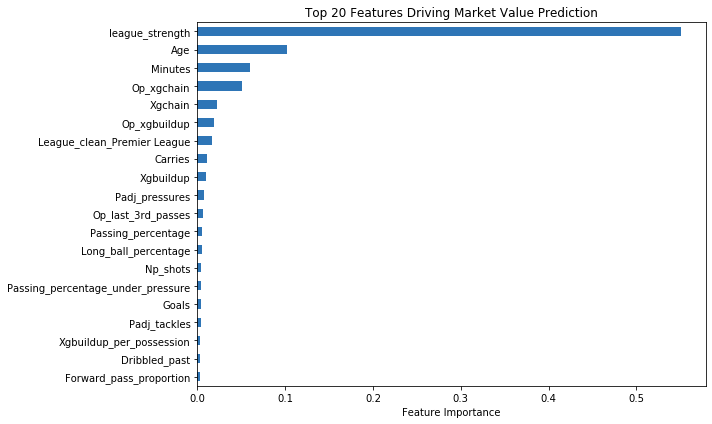

Feature importance is averaged across CV folds (no full-fit leakage).
The ranking score uses the out-of-fold residual (Value IQ).


In [9]:
# Feature importance: fold-averaged (no full-fit data leakage)
feat_imp = pd.Series(_fold_avg_importances, index=_fold_feature_names).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
feat_imp.head(20).sort_values(ascending=True).plot(kind="barh", ax=ax, color="#2E75B6")
ax.set_xlabel("Feature Importance")
ax.set_title("Top 20 Features Driving Market Value Prediction")
plt.tight_layout()
plt.show()

print("Feature importance is averaged across CV folds (no full-fit leakage).")
print("The ranking score uses the out-of-fold residual (Value IQ).")

### Value Intelligence: Out-of-Fold Predicted vs Actual

Players above the diagonal line look **undervalued on the out-of-fold model**, meaning the model predicted a higher value than the player's current observed market value.


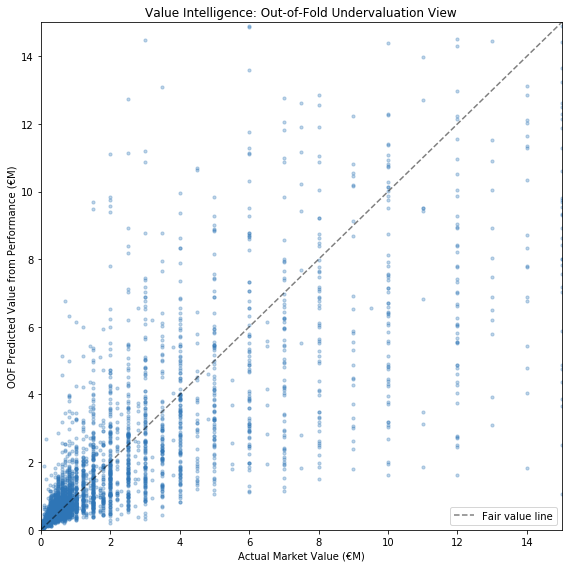

In [10]:
fig, ax = plt.subplots(figsize=(8, 8))

val_plot = market[market["value_pred_log_oof"].notna()].copy()
actual = val_plot["Value_EUR"]
predicted = np.expm1(val_plot["value_pred_log_oof"])

ax.scatter(actual / 1e6, predicted / 1e6, alpha=0.3, s=10, c="#2E75B6")

# Diagonal
lim = max(actual.max(), predicted.max()) / 1e6
ax.plot([0, lim], [0, lim], "k--", alpha=0.5, label="Fair value line")

ax.set_xlabel("Actual Market Value (€M)")
ax.set_ylabel("OOF Predicted Value from Performance (€M)")
ax.set_title("Value Intelligence: Out-of-Fold Undervaluation View")
ax.legend()
ax.set_xlim(0, min(lim, 15))
ax.set_ylim(0, min(lim, 15))
plt.tight_layout()
plt.show()


## 7) Build Diagnostic Z-Scores and Final Recruitment Ranking

This step keeps **metric-level z-scores** for explainability and radar comparisons, but it no longer uses the old VFM layer in the final ranking.

Design choice:
- Metric z-scores are retained as a transparent diagnostic layer.
- The final ranking combines **Vacancy Fit** and **Value IQ** only.
- This avoids double-counting performance information across multiple score layers.


In [11]:
# Build diagnostic z-scores for explainability and radar comparison
group = market["pos_bucket"]

# zscore_group and LOWER_IS_BETTER already defined in Cell 11; reuse them here.
# Lower-is-better set for diagnostic z-scores (same as LOWER_IS_BETTER_LOCAL from Cell 11).
LOWER_IS_BETTER = LOWER_IS_BETTER_LOCAL

all_metrics_present = [c for c in OUTFIELD_METRICS if c in market.columns]
all_metrics_present = list(dict.fromkeys(all_metrics_present))

for m in all_metrics_present:
    market[m] = pd.to_numeric(market[m], errors="coerce")
    z = zscore_group(market[m], group)
    if m in LOWER_IS_BETTER:
        z = -z
    market[f"{m}_z"] = z

# Optional diagnostic: role-quality summary, not used directly in the final score
def row_role_quality(row):
    bucket = row["pos_bucket"]
    metrics = get_role_metrics(bucket)
    vals = [row.get(f"{m}_z") for m in metrics if f"{m}_z" in row.index and pd.notna(row.get(f"{m}_z"))]
    return np.mean(vals) if vals else np.nan

market["role_quality_diag"] = market.apply(row_role_quality, axis=1)

# === FINAL RANKING SCORE ===
# Fixed weighted average: NaN columns are excluded from BOTH numerator and denominator
# so that missing data neither inflates nor deflates the score.
active_weights = {
    "vacancy_fit": W_VACANCY,
    "value_iq_score": W_VALUE_IQ,
}

numerator = pd.Series(0.0, index=market.index)
denominator = pd.Series(0.0, index=market.index)

for col, weight in active_weights.items():
    mask = market[col].notna()
    numerator += weight * market[col].where(mask, 0.0)
    denominator += weight * mask.astype(float)

raw_score = numerator / denominator.replace(0, np.nan)

# Minutes-based reliability weight: dampens scores for low-sample players.
# Players above FULL_RELIABILITY_MINUTES get weight=1.0; below that, linear ramp
# down to MIN_RELIABILITY_WEIGHT. This avoids per-90 noise dominating the ranking.
market["reliability_weight"] = (
    (market["Minutes"] / FULL_RELIABILITY_MINUTES)
    .clip(lower=MIN_RELIABILITY_WEIGHT, upper=1.0)
)
market["final_score_raw"] = raw_score
market["final_score"] = raw_score * market["reliability_weight"]

print("Final ranking score computed from Vacancy Fit and Value IQ (with reliability dampening).")
print(market[["final_score_raw", "reliability_weight", "final_score"]].describe())


Final ranking score computed from Vacancy Fit and Value IQ (with reliability dampening).
       final_score_raw  reliability_weight  final_score
count      4962.000000         4962.000000  4962.000000
mean          0.428588            0.775468     0.334172
std           0.111448            0.252411     0.142440
min           0.054010            0.300000     0.017940
25%           0.353848            0.553701     0.217798
50%           0.425749            0.888746     0.335330
75%           0.501817            1.000000     0.437434
max           0.873937            1.000000     0.873937


## 8) Apply Filters & Build Role Boards

In [12]:

# Apply scouting filters
candidates = market.copy()

# Exclude configured teams (club-agnostic by default).
if EXCLUDE_TEAMS:
    pat = "|".join([re.escape(t) for t in EXCLUDE_TEAMS])
    candidates = candidates[~candidates["Team_clean"].str.contains(pat, case=False, na=False)]

# Age filter
if AGE_MAX:
    candidates = candidates[(candidates["Age"].isna()) | (candidates["Age"] <= AGE_MAX)]

# Budget filter
if BUDGET_MAX_EUR:
    candidates = candidates[
        (candidates["Value_EUR"].isna()) | (candidates["Value_EUR"] <= BUDGET_MAX_EUR)
    ]

# Optional side filter for targeted portfolio views
if TARGET_SIDE in {"Left", "Right", "Centre"}:
    candidates = candidates[
        candidates["primary_side"].eq(TARGET_SIDE)
        | candidates["secondary_side"].eq(TARGET_SIDE)
        | (~candidates["is_side_specific_role"] & (TARGET_SIDE == "Centre"))
    ]

# Require valid value for the Value-IQ layer
candidates = candidates[candidates["Value_EUR"].notna()].copy()

# For readability in visible boards, keep only the latest / best row per player AFTER scoring.
# This preserves player-team-season scoring internally while avoiding duplicate players in the display layer.
if ONE_ROW_PER_PLAYER_IN_RANKING:
    candidates = (
        candidates.sort_values(
            ["Season_sort_key", "final_score", "minutes_evidence_sort", "Minutes"],
            ascending=[False, False, False, False]
        )
        .drop_duplicates("ID", keep="first")
        .copy()
    )

# Board-specific ranking is the main visible output.
candidates = candidates[candidates["role_board"].notna()].copy()
candidates["board_rank"] = (
    candidates.groupby("role_board")["final_score"]
    .rank(method="first", ascending=False)
    .astype(int)
)

# Keep a diagnostic overall rank if needed, but do not use it as the main portfolio view.
candidates = candidates.sort_values(
    ["role_board", "board_rank", "final_score", "minutes_evidence_sort", "Minutes"],
    ascending=[True, True, False, False, False]
).reset_index(drop=True)
candidates["overall_rank_diag"] = candidates["final_score"].rank(method="first", ascending=False).astype(int)

print(f"Candidates after filters: {len(candidates)}")
print("Role boards available:")
display(candidates["role_board"].value_counts().rename_axis("role_board").reset_index(name="n_players"))

show_cols = [
    "record_key", "ID", "Team_clean", "League_clean", "Season_clean",
    "pos_bucket", "role_board", "board_rank",
    "primary_side", "secondary_side",
    "comparison_bucket_group", "side_group_fallback_used",
    "Age", "Minutes", "minutes_evidence", "Value_EUR",
    "functional_fit", "squad_complementarity", "vacancy_fit",
    "value_iq_score", "league_translation_risk", "league_translation_risk_label",
    "reliability_weight", "final_score_raw", "final_score", "overall_rank_diag"
]
show_cols = [c for c in show_cols if c in candidates.columns]

role_board_tables = {
    board: grp.sort_values(["board_rank", "final_score", "minutes_evidence_sort", "Minutes"], ascending=[True, False, False, False]).copy()
    for board, grp in candidates.groupby("role_board", sort=True)
}

for board, board_df in role_board_tables.items():
    print(f"\n=== {board} board ===")
    display(board_df[show_cols].head(10))


Candidates after filters: 2839
Role boards available:


,role_board,n_players
0,CB,595
1,DMF,494
2,CF,393
3,Right FB/WB,306
4,Left FB/WB,303
5,Left Wide,216
6,Right Wide,209
7,AMF,174
8,CMF,149



=== AMF board ===


,record_key,ID,Team_clean,League_clean,Season_clean,pos_bucket,role_board,board_rank,primary_side,secondary_side,comparison_bucket_group,side_group_fallback_used,Age,Minutes,minutes_evidence,Value_EUR,functional_fit,squad_complementarity,vacancy_fit,value_iq_score,league_translation_risk,league_translation_risk_label,reliability_weight,final_score_raw,final_score,overall_rank_diag
0,16765__Metz__2024/2025,16765,Metz,Ligue 2,2024/2025,AMF,AMF,1,Centre,Left,unavailable,True,29,3314.033,High,4000000.0,0.758506,NaN,0.455103,0.662222,0.0,Low,1.000000,0.517239,0.517239,318
1,94977__RWDM__2024/2025,94977,RWDM,Challenger Pro League,2024/2025,AMF,AMF,2,Centre,Left,unavailable,True,22,2416.800,High,1000000.0,0.598830,NaN,0.359298,0.811220,1.0,High,1.000000,0.494875,0.494875,434
2,80871__Sirius__2025,80871,Sirius,Allsvenskan,2025,AMF,AMF,3,Centre,Right,unavailable,True,22,2908.300,High,3000000.0,0.623842,NaN,0.374305,0.680296,0.0,Low,1.000000,0.466102,0.466102,581
3,72248__Luzern__2024/2025,72248,Luzern,Super League,2024/2025,AMF,AMF,4,Centre,Right,unavailable,True,26,2337.334,High,1800000.0,0.590512,NaN,0.354307,0.698331,0.0,Low,1.000000,0.457514,0.457514,622
4,88382__Beerschot__2024/2025,88382,Beerschot,Jupiler Pro League,2024/2025,AMF,AMF,5,Centre,Left,unavailable,True,24,1771.867,Medium,750000.0,0.503212,NaN,0.301927,0.839909,0.0,Low,0.984371,0.463322,0.456080,630
5,25052__Hartberg__2024/2025,25052,Hartberg,Bundesliga,2024/2025,AMF,AMF,6,Centre,Left,unavailable,True,28,1903.367,High,600000.0,0.496468,NaN,0.297881,0.781510,0.0,Low,1.000000,0.442970,0.442970,720
6,38460__Cardiff City__2024/2025,38460,Cardiff City,Championship,2024/2025,AMF,AMF,7,Centre,Right,unavailable,True,23,2795.683,High,1400000.0,0.397023,NaN,0.238214,0.887401,0.0,Low,1.000000,0.432970,0.432970,772
7,90636__Nurnberg__2024/2025,90636,Nurnberg,2. Bundesliga,2024/2025,AMF,AMF,8,Centre,Right,unavailable,True,27,2931.666,High,2200000.0,0.517500,NaN,0.310500,0.711914,0.0,Low,1.000000,0.430924,0.430924,789
8,54415__Caen__2024/2025,54415,Caen,Ligue 2,2024/2025,AMF,AMF,9,Centre,Right,unavailable,True,25,2215.033,High,1200000.0,0.493117,NaN,0.295870,0.737876,0.0,Low,1.000000,0.428472,0.428472,805
9,15392__Rapid Wien__2024/2025,15392,Rapid Wien,Bundesliga,2024/2025,AMF,AMF,10,Centre,Right,unavailable,True,30,1849.000,High,700000.0,0.485758,NaN,0.291455,0.741194,0.0,Low,1.000000,0.426377,0.426377,823



=== CB board ===


...

,record_key,ID,Team_clean,League_clean,Season_clean,pos_bucket,role_board,board_rank,primary_side,secondary_side,comparison_bucket_group,side_group_fallback_used,Age,Minutes,minutes_evidence,Value_EUR,functional_fit,squad_complementarity,vacancy_fit,value_iq_score,league_translation_risk,league_translation_risk_label,reliability_weight,final_score_raw,final_score,overall_rank_diag
2108,56947__Guingamp__2024/2025,56947,Guingamp,Ligue 2,2024/2025,LM,Left Wide,1,Left,Right,"LM,LW",False,22,2957.884,High,3000000.0,0.566963,0.969239,0.727874,0.742832,0.0,Low,1.000000,0.732361,0.732361,5
2109,82254__Sporting Charleroi__2024/2025,82254,Sporting Charleroi,Jupiler Pro League,2024/2025,LW,Left Wide,2,Left,Left,"LM,LW",False,24,2888.550,High,3000000.0,0.544408,0.700450,0.606825,0.820550,0.0,Low,1.000000,0.670943,0.670943,18
2110,83606__Rosenborg BK__2025,83606,Rosenborg BK,Eliteserien,2025,LW,Left Wide,3,Left,Left,"LM,LW",False,24,2383.383,High,2000000.0,0.619807,1.000000,0.771884,0.408424,0.0,Low,1.000000,0.662846,0.662846,21
2111,94739__West Bromwich Albion__2024/2025,94739,West Bromwich Albion,Championship,2024/2025,LM,Left Wide,4,Left,Left,"LM,LW",False,26,2240.350,High,3000000.0,0.488355,0.750000,0.593013,0.771769,0.0,Low,1.000000,0.646640,0.646640,35
2112,43719__Magdeburg__2024/2025,43719,Magdeburg,2. Bundesliga,2024/2025,LW,Left Wide,5,Left,Right,"LM,LW",False,21,2209.233,High,4000000.0,0.554618,0.750000,0.632771,0.672475,0.0,Low,1.000000,0.644682,0.644682,38
2113,75185__Viking__2025,75185,Viking,Eliteserien,2025,LM,Left Wide,6,Left,Left,"LM,LW",False,20,1860.934,High,5000000.0,0.604237,0.864853,0.708483,0.448618,0.0,Low,1.000000,0.630524,0.630524,53
2114,45790__Malmo FF__2025,45790,Malmo FF,Allsvenskan,2025,LW,Left Wide,7,Left,Left,"LM,LW",False,27,1668.934,Medium,1000000.0,0.588297,0.810811,0.677303,0.626203,0.0,Low,0.927186,0.661973,0.613771,68
2115,53147__Hamburger SV__2024/2025,53147,Hamburger SV,2. Bundesliga,2024/2025,LW,Left Wide,8,Left,Left,"LM,LW",False,30,2591.250,High,3500000.0,0.685605,0.752047,0.712182,0.338526,0.0,Low,1.000000,0.600085,0.600085,84
2116,92862__Basel__2024/2025,92862,Basel,Super League,2024/2025,LW,Left Wide,9,Left,Centre,"LM,LW",False,23,2506.800,High,10000000.0,0.634129,0.798315,0.699804,0.335626,0.0,Low,1.000000,0.590550,0.590550,96
2117,89082__Beerschot__2024/2025,89082,Beerschot,Jupiler Pro League,2024/2025,LW,Left Wide,10,Left,Left,"LM,LW",False,26,1915.750,High,1700000.0,0.467636,0.750000,0.580582,0.575468,0.0,Low,1.000000,0.579047,0.579047,116



=== Right FB/WB board ===


,record_key,ID,Team_clean,League_clean,Season_clean,pos_bucket,role_board,board_rank,primary_side,secondary_side,comparison_bucket_group,side_group_fallback_used,Age,Minutes,minutes_evidence,Value_EUR,functional_fit,squad_complementarity,vacancy_fit,value_iq_score,league_translation_risk,league_translation_risk_label,reliability_weight,final_score_raw,final_score,overall_rank_diag
2324,60131__Cercle Brugge__2024/2025,60131,Cercle Brugge,Jupiler Pro League,2024/2025,RWB,Right FB/WB,1,Right,Right,"RFB,RWB",False,21,1972.167,High,1200000.0,0.649366,0.910755,0.753922,0.689828,0.0,Low,1.000000,0.734694,0.734694,4
2325,70926__Kashiwa Reysol__2025,70926,Kashiwa Reysol,J1 League,2025,RWB,Right FB/WB,2,Right,NaN,"RFB,RWB",False,26,2658.467,High,800000.0,0.612865,0.766466,0.674305,0.780424,0.0,Low,1.000000,0.706141,0.706141,8
2326,29340__Altach__2024/2025,29340,Altach,Bundesliga,2024/2025,RWB,Right FB/WB,3,Right,Right,"RFB,RWB",False,28,2514.083,High,400000.0,0.494727,0.827995,0.628034,0.746072,0.0,Low,1.000000,0.663446,0.663446,20
2327,59252__Hammarby__2025,59252,Hammarby,Allsvenskan,2025,RFB,Right FB/WB,4,Right,Right,"RFB,RWB",False,21,2279.934,High,2000000.0,0.720529,0.763229,0.737609,0.471803,0.0,Low,1.000000,0.657867,0.657867,23
2328,72137__Austria Klagenfurt__2024/2025,72137,Austria Klagenfurt,Bundesliga,2024/2025,RWB,Right FB/WB,5,Right,Right,"RFB,RWB",False,26,1711.150,Medium,350000.0,0.531627,0.861899,0.663736,0.726865,0.0,Low,0.950639,0.682675,0.648977,30
2329,45568__RWDM__2024/2025,45568,RWDM,Challenger Pro League,2024/2025,RFB,Right FB/WB,6,Right,Right,"RFB,RWB",False,29,2769.966,High,700000.0,0.641656,0.833333,0.718327,0.475576,1.0,High,1.000000,0.645502,0.645502,37
2330,92994__Brann__2025,92994,Brann,Eliteserien,2025,RFB,Right FB/WB,7,Right,Left,"RFB,RWB",False,21,1502.233,Medium,400000.0,0.723662,0.784939,0.748172,0.765414,0.0,Low,0.834574,0.753345,0.628722,55
2331,43370__Sint-Truiden__2024/2025,43370,Sint-Truiden,Jupiler Pro League,2024/2025,RWB,Right FB/WB,8,Right,Right,"RFB,RWB",False,24,2399.166,High,2000000.0,0.555066,0.679063,0.604665,0.682635,0.0,Low,1.000000,0.628056,0.628056,56
2332,58348__Antwerp__2024/2025,58348,Antwerp,Jupiler Pro League,2024/2025,RFB,Right FB/WB,9,Right,Right,"RFB,RWB",False,26,2102.217,High,2500000.0,0.610329,0.736915,0.660964,0.544476,0.0,Low,1.000000,0.626017,0.626017,58
2333,57367__Swansea City__2024/2025,57367,Swansea City,Championship,2024/2025,RFB,Right FB/WB,10,Right,Right,"RFB,RWB",False,26,3770.733,High,800000.0,0.503408,0.408286,0.465359,0.990849,0.0,Low,1.000000,0.623006,0.623006,59



=== Right Wide board ===


,record_key,ID,Team_clean,League_clean,Season_clean,pos_bucket,role_board,board_rank,primary_side,secondary_side,comparison_bucket_group,side_group_fallback_used,Age,Minutes,minutes_evidence,Value_EUR,functional_fit,squad_complementarity,vacancy_fit,value_iq_score,league_translation_risk,league_translation_risk_label,reliability_weight,final_score_raw,final_score,overall_rank_diag
2630,62635__Fulham__2024/2025,62635,Fulham,Premier League,2024/2025,RW,Right Wide,1,Right,Left,"RM,RW",False,29,1972.667,High,9000000.0,0.551622,0.750000,0.630973,0.704781,0.0,Low,1.000000,0.653115,0.653115,27
2631,75873__Lommel__2024/2025,75873,Lommel,Challenger Pro League,2024/2025,RM,Right Wide,2,Right,Right,"RM,RW",False,21,2574.567,High,800000.0,0.458482,0.588417,0.510456,0.776729,1.0,High,1.000000,0.590338,0.590338,97
2632,94816__Patro Eisden__2024/2025,94816,Patro Eisden,Challenger Pro League,2024/2025,RW,Right Wide,3,Right,Right,"RM,RW",False,22,2901.234,High,800000.0,0.602843,0.559859,0.585649,0.538694,1.0,High,1.000000,0.571563,0.571563,133
2633,52299__West Bromwich Albion__2024/2025,52299,West Bromwich Albion,Championship,2024/2025,RW,Right Wide,4,Right,Right,"RM,RW",False,22,3072.067,High,10000000.0,0.480563,0.990109,0.684382,0.305648,0.0,Low,1.000000,0.570762,0.570762,136
2634,74170__Bristol City__2024/2025,74170,Bristol City,Championship,2024/2025,RW,Right Wide,5,Right,Right,"RM,RW",False,24,1901.033,High,1000000.0,0.361677,0.495566,0.415233,0.823466,0.0,Low,1.000000,0.537703,0.537703,235
2635,13338__Darmstadt 98__2024/2025,13338,Darmstadt 98,2. Bundesliga,2024/2025,RW,Right Wide,6,Right,Left,"RM,RW",False,28,1510.333,Medium,750000.0,0.573747,0.750000,0.644248,0.597120,0.0,Low,0.839074,0.630110,0.528709,273
2636,23418__Queens Park Rangers__2024/2025,23418,Queens Park Rangers,Championship,2024/2025,RW,Right Wide,7,Right,Right,"RM,RW",False,28,2979.650,High,600000.0,0.308770,0.577465,0.416248,0.785050,0.0,Low,1.000000,0.526889,0.526889,285
2637,98714__Pau__2024/2025,98714,Pau,Ligue 2,2024/2025,RW,Right Wide,8,Right,Left,"RM,RW",False,25,1583.533,Medium,400000.0,0.485869,0.750000,0.591521,0.597420,0.0,Low,0.879741,0.593291,0.521942,304
2638,11214__Gamba Osaka__2025,11214,Gamba Osaka,J1 League,2025,RW,Right Wide,9,Right,Left,"RM,RW",False,28,2215.367,High,850000.0,0.500051,0.500000,0.500030,0.565836,0.0,Low,1.000000,0.519772,0.519772,309
2639,13810__Club Brugge__2024/2025,13810,Club Brugge,Jupiler Pro League,2024/2025,RW,Right Wide,10,Right,Left,"RM,RW",False,20,1343.533,Medium,8000000.0,0.678873,0.989437,0.803099,0.396462,0.0,Low,0.746407,0.681108,0.508384,367


## 9) Select Final Shortlist (Board-Aware Portfolio Assembly)

In [13]:

SHORTLIST_BOARD_TARGETS_RESOLVED = {
    group_name: set(board_names)
    for group_name, board_names in SHORTLIST_BOARD_TARGETS.items()
}

def select_portfolio_by_board(cands, n, shortlist_board_targets, max_per_board):
    chosen_rows = []
    chosen_record_keys = set()
    board_counts = {}

    def can_take(row):
        board = row["role_board"]
        return board_counts.get(board, 0) < max_per_board

    def take(row):
        board = row["role_board"]
        chosen_rows.append(row)
        chosen_record_keys.add(row["record_key"])
        board_counts[board] = board_counts.get(board, 0) + 1

    # 1) Cover required board groups first using board-local ranking.
    for target_name, eligible_boards in shortlist_board_targets.items():
        pool = cands[cands["role_board"].isin(eligible_boards)].copy()
        pool = pool[~pool["record_key"].isin(chosen_record_keys)]
        pool = pool.sort_values(
            ["board_rank", "final_score", "minutes_evidence_sort", "Minutes"],
            ascending=[True, False, False, False]
        )
        for _, row in pool.iterrows():
            if can_take(row):
                take(row)
                break

    # 2) Fill the remaining slots by preferring board leaders first, then score.
    remainder = cands[~cands["record_key"].isin(chosen_record_keys)].copy()
    remainder = remainder.sort_values(
        ["board_rank", "final_score", "minutes_evidence_sort", "Minutes"],
        ascending=[True, False, False, False]
    )

    for _, row in remainder.iterrows():
        if len(chosen_rows) >= n:
            break
        if can_take(row):
            take(row)

    final_df = pd.DataFrame(chosen_rows).copy()
    if len(final_df):
        final_df = final_df.sort_values(
            ["board_rank", "final_score", "minutes_evidence_sort", "Minutes"],
            ascending=[True, False, False, False]
        ).reset_index(drop=True)
    return final_df

final = select_portfolio_by_board(
    candidates,
    N_SHORTLIST,
    SHORTLIST_BOARD_TARGETS_RESOLVED,
    MAX_PER_BOARD
)

print(f"=== FINAL {N_SHORTLIST} SHORTLIST ===\n")
for _, r in final.iterrows():
    print(
        f"Board: {r['role_board']} | Board rank: {int(r['board_rank'])} | "
        f"ID: {r['ID']} | {r['pos_bucket']} ({r.get('primary_side', 'Unknown')})"
    )
    print(f"  Team/season: {r['Team_clean']} ({r['League_clean']}, {r['Season_clean']})")
    print(f"  Record key: {r.get('record_key', 'n/a')}")
    print(
        f"  Value: €{r['Value_EUR']:,.0f} | Minutes: {r['Minutes']:.0f} "
        f"| Minutes evidence: {r.get('minutes_evidence', 'Unknown')}"
    )
    print(
        f"  Reliability: {r.get('reliability_weight', 0):.2f} | Functional: {r['functional_fit']:.3f} | "
        f"Complementarity: {r['squad_complementarity']:.3f} | Vacancy: {r['vacancy_fit']:.3f} | "
        f"ValueIQ (OOF): {r['value_iq_score']:.3f} | FinalScore: {r['final_score']:.3f}"
    )
    print(
        f"  Comparison group: {r.get('comparison_bucket_group', 'n/a')} | "
        f"Side-group fallback: {r.get('side_group_fallback_used', 'n/a')}"
    )
    print()

display(final[[c for c in show_cols if c in final.columns]])


=== FINAL 4 SHORTLIST ===

Board: DMF | Board rank: 1 | ID: 38930 | DMF (Centre)
  Team/season: Hacken (Allsvenskan, 2025)
  Record key: 38930__Hacken__2025
  Value: €800,000 | Minutes: 2391 | Minutes evidence: High
  Reliability: 1.00 | Functional: 0.793 | Complementarity: 0.973 | Vacancy: 0.865 | ValueIQ (OOF): 0.611 | FinalScore: 0.789
  Comparison group: DMF | Side-group fallback: False

Board: CB | Board rank: 1 | ID: 87830 | RCB (Right)
  Team/season: Mechelen (Jupiler Pro League, 2024/2025)
  Record key: 87830__Mechelen__2024/2025
  Value: €1,200,000 | Minutes: 3102 | Minutes evidence: High
  Reliability: 1.00 | Functional: 0.547 | Complementarity: 0.775 | Vacancy: 0.638 | ValueIQ (OOF): 0.985 | FinalScore: 0.742
  Comparison group: RCB | Side-group fallback: False

Board: Right FB/WB | Board rank: 1 | ID: 60131 | RWB (Right)
  Team/season: Cercle Brugge (Jupiler Pro League, 2024/2025)
  Record key: 60131__Cercle Brugge__2024/2025
  Value: €1,200,000 | Minutes: 1972 | Minutes ev

,record_key,ID,Team_clean,League_clean,Season_clean,pos_bucket,role_board,board_rank,primary_side,secondary_side,comparison_bucket_group,side_group_fallback_used,Age,Minutes,minutes_evidence,Value_EUR,functional_fit,squad_complementarity,vacancy_fit,value_iq_score,league_translation_risk,league_translation_risk_label,reliability_weight,final_score_raw,final_score,overall_rank_diag
0,38930__Hacken__2025,38930,Hacken,Allsvenskan,2025,DMF,DMF,1,Centre,Right,DMF,False,21,2390.800,High,800000.0,0.793283,0.973138,0.865225,0.610550,0.0,Low,1.0,0.788822,0.788822,1
1,87830__Mechelen__2024/2025,87830,Mechelen,Jupiler Pro League,2024/2025,RCB,CB,1,Right,Left,RCB,False,25,3102.067,High,1200000.0,0.546891,0.775134,0.638188,0.985090,0.0,Low,1.0,0.742259,0.742259,3
2,60131__Cercle Brugge__2024/2025,60131,Cercle Brugge,Jupiler Pro League,2024/2025,RWB,Right FB/WB,1,Right,Right,"RFB,RWB",False,21,1972.167,High,1200000.0,0.649366,0.910755,0.753922,0.689828,0.0,Low,1.0,0.734694,0.734694,4
3,56947__Guingamp__2024/2025,56947,Guingamp,Ligue 2,2024/2025,LM,Left Wide,1,Left,Right,"LM,LW",False,22,2957.884,High,3000000.0,0.566963,0.969239,0.727874,0.742832,0.0,Low,1.0,0.732361,0.732361,5


## 10) Benchmark Percentile Table for Shortlist

This section computes **role-specific percentile ranks** for each shortlisted player against a clearly defined peer group.

Design choice:
- The table provides the raw data needed to write scouting narratives in a presentation.
- It does NOT generate template text — narratives are written by the analyst with tactical context that no model can capture.
- Peer group priority: (1) same league-season + role group, (2) dataset-wide role group.


In [14]:
def safe_percentile_rank(ref_series, value):
    ref = pd.to_numeric(ref_series, errors="coerce").dropna()
    if len(ref) < 3 or pd.isna(value):
        return np.nan
    return float((ref <= value).mean())

def build_explain_reference(row, market_df, min_n=8):
    """
    Reference-group logic for benchmark-relative percentile computation.
    Priority:
    1) Same league + season + side-aware comparison group
    2) Same side-aware comparison group across the dataset
    3) Same role bucket across the dataset
    """
    league = row.get("League_clean")
    season = row.get("Season_clean")
    comp_group = row.get("comparison_bucket_group")
    bucket = row.get("pos_bucket")

    ref1 = market_df.copy()
    if pd.notna(league):
        ref1 = ref1[ref1["League_clean"].eq(league)]
    if pd.notna(season):
        ref1 = ref1[ref1["Season_clean"].eq(season)]
    if pd.notna(comp_group) and str(comp_group) not in {"unavailable", "nan"} and "comparison_bucket_group" in ref1.columns:
        ref1 = ref1[ref1["comparison_bucket_group"].eq(comp_group)]
    if len(ref1) >= min_n:
        return ref1, f"{league} {season} peers in {comp_group}", len(ref1)

    ref2 = market_df.copy()
    if pd.notna(comp_group) and str(comp_group) not in {"unavailable", "nan"} and "comparison_bucket_group" in ref2.columns:
        ref2 = ref2[ref2["comparison_bucket_group"].eq(comp_group)]
    if len(ref2) >= min_n:
        return ref2, f"dataset peers in {comp_group}", len(ref2)

    ref3 = market_df.copy()
    if pd.notna(bucket):
        ref3 = ref3[ref3["pos_bucket"].eq(bucket)]
    return ref3, f"dataset peers in {bucket}", len(ref3)


def build_percentile_table(shortlist_df, market_df):
    """
    For each shortlisted player, compute percentile ranks on their role-specific
    metrics against the best available peer group. Returns a tidy DataFrame
    suitable for export and PowerPoint slides.
    """
    rows = []
    for _, player in shortlist_df.iterrows():
        bucket = player["pos_bucket"]
        metrics = get_role_metrics(bucket)
        ref_df, ref_label, ref_n = build_explain_reference(player, market_df, min_n=8)

        for m in metrics:
            col_z = f"{m}_z"
            if col_z not in player.index or pd.isna(player.get(col_z)):
                continue
            if col_z not in ref_df.columns:
                continue

            pct = safe_percentile_rank(ref_df[col_z], float(player[col_z]))
            rows.append({
                "ID": player["ID"],
                "record_key": player.get("record_key"),
                "role_board": player.get("role_board"),
                "pos_bucket": bucket,
                "metric": m,
                "z_score": round(float(player[col_z]), 3),
                "percentile": round(pct, 3) if pd.notna(pct) else np.nan,
                "peer_group": ref_label,
                "peer_n": ref_n,
            })

    return pd.DataFrame(rows)


# Build the benchmark table
benchmark_table = build_percentile_table(final, market)

# Display: pivot to wide format for quick comparison
if len(benchmark_table):
    pivot = benchmark_table.pivot_table(
        index=["ID", "role_board", "pos_bucket"],
        columns="metric",
        values="percentile",
        aggfunc="first"
    )
    print("=== Benchmark Percentile Table (shortlisted players) ===\n")
    display(pivot.style.format("{:.0%}").background_gradient(cmap="RdYlGn", vmin=0, vmax=1))

    # Summary: top 3 strengths and bottom 2 weaknesses per player
    print("\n=== Per-Player Strengths / Weaknesses Summary ===\n")
    for pid, grp in benchmark_table.groupby("ID"):
        board = grp["role_board"].iloc[0]
        sorted_metrics = grp.dropna(subset=["percentile"]).sort_values("percentile", ascending=False)
        top3 = sorted_metrics.head(3)
        bot2 = sorted_metrics.tail(2)
        print(f"ID {pid} ({board}):")
        print(f"  Strengths: {', '.join(f'{r.metric} (P{r.percentile:.0%})' for _, r in top3.iterrows())}")
        print(f"  Weaknesses: {', '.join(f'{r.metric} (P{r.percentile:.0%})' for _, r in bot2.iterrows())}")
        print(f"  Peer group: {grp['peer_group'].iloc[0]} (n={grp['peer_n'].iloc[0]})")
        print()
else:
    print("No benchmark data available.")


=== Benchmark Percentile Table (shortlisted players) ===



,,metric,Aerial_percentage,Aerial_won,Attempted_pass_length,Ball_recoveries,Block_per_shot,Carries,Carry_length,Clearance,Crosses_completed,Crossing_percentage,Dispossessed,Dribbled_past,Dribbles_successful,Errors,Goal_conversion,Interceptions,Key_passes,Long_ball_percentage,Long_balls,Np_xg,Op_passes,Padj_Clearances,Padj_interceptions,Padj_pressures,Padj_tackles,Pass_and_carry_last_3rd,Passing_percentage,Passing_percentage_under_pressure,Pressing_distance,Pressures,Shot_target_percentage,Successful_pressures,Tackles,Touches_in_box,Xa,Xgbuildup,Xgchain
ID,role_board,pos_bucket,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
38930,DMF,DMF,nan%,nan%,nan%,97%,nan%,nan%,nan%,nan%,nan%,nan%,nan%,nan%,nan%,100%,nan%,nan%,nan%,nan%,92%,nan%,95%,nan%,97%,nan%,95%,nan%,92%,82%,nan%,49%,nan%,54%,nan%,nan%,nan%,95%,nan%
56947,Left Wide,LM,nan%,nan%,nan%,nan%,nan%,88%,85%,nan%,92%,96%,35%,nan%,73%,nan%,31%,nan%,96%,nan%,nan%,31%,nan%,nan%,nan%,nan%,nan%,nan%,nan%,nan%,nan%,nan%,69%,nan%,nan%,73%,88%,nan%,81%
60131,Right FB/WB,RWB,nan%,nan%,nan%,100%,nan%,6%,nan%,nan%,46%,94%,nan%,nan%,69%,nan%,nan%,63%,nan%,nan%,nan%,nan%,nan%,nan%,nan%,100%,nan%,43%,nan%,nan%,97%,nan%,nan%,94%,97%,nan%,nan%,40%,nan%
87830,CB,RCB,59%,88%,88%,53%,47%,nan%,nan%,31%,nan%,nan%,nan%,19%,nan%,100%,nan%,81%,nan%,66%,91%,nan%,nan%,53%,97%,nan%,94%,nan%,53%,50%,nan%,84%,nan%,nan%,84%,nan%,nan%,nan%,nan%



=== Per-Player Strengths / Weaknesses Summary ===

ID 38930 (DMF):
  Strengths: Errors (P100%), Padj_interceptions (P97%), Ball_recoveries (P97%)
  Weaknesses: Successful_pressures (P54%), Pressures (P49%)
  Peer group: Allsvenskan 2025 peers in DMF (n=61)

ID 56947 (Left Wide):
  Strengths: Crossing_percentage (P96%), Key_passes (P96%), Crosses_completed (P92%)
  Weaknesses: Np_xg (P31%), Goal_conversion (P31%)
  Peer group: Ligue 2 2024/2025 peers in LM,LW (n=26)

ID 60131 (Right FB/WB):
  Strengths: Padj_pressures (P100%), Ball_recoveries (P100%), Tackles (P97%)
  Weaknesses: Xgbuildup (P40%), Carries (P6%)
  Peer group: Jupiler Pro League 2024/2025 peers in RFB,RWB (n=35)

ID 87830 (CB):
  Strengths: Errors (P100%), Padj_interceptions (P97%), Padj_tackles (P94%)
  Weaknesses: Clearance (P31%), Dribbled_past (P19%)
  Peer group: Jupiler Pro League 2024/2025 peers in RCB (n=32)



## 11) Radar Comparison: Candidate vs Club Best

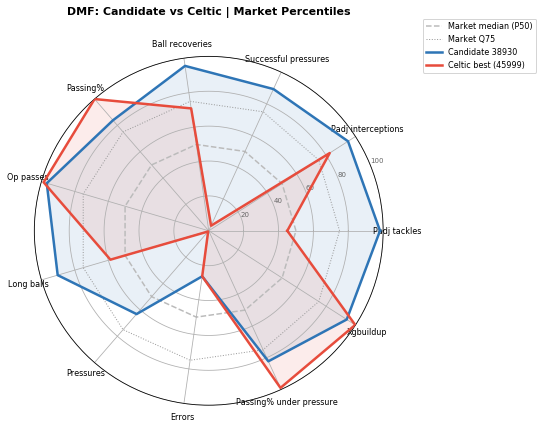

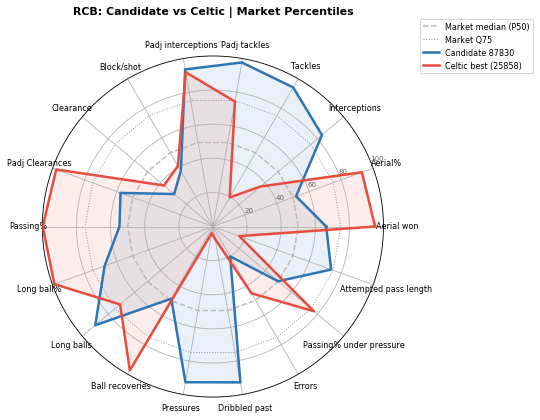

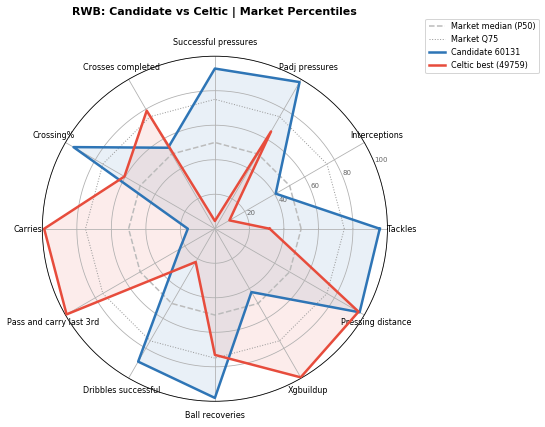

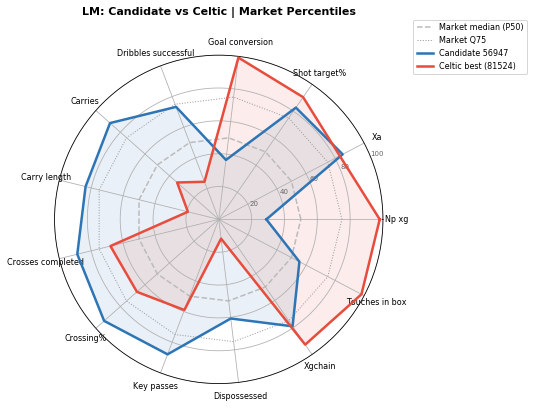

In [15]:
def percentile_within(ref, x):
    base = pd.to_numeric(ref, errors="coerce").dropna()
    if base.empty or pd.isna(x):
        return np.nan
    tmp = pd.concat([base, pd.Series([x])], ignore_index=True)
    return float(tmp.rank(pct=True).iloc[-1] * 100.0)

def short_label(s):
    return s.replace("_percentage", "%").replace("_per_", "/").replace("_", " ")

def radar_compare(rows, labels, bucket, title, market_ref):
    """
    Improved radar: candidate vs club incumbent, with market median and Q75 reference lines.
    """
    metrics = get_role_metrics(bucket)
    equiv = ROLE_EQUIV.get(bucket, {bucket})
    ref_bucket = market_ref[market_ref["pos_bucket"].isin(equiv)]
    if ref_bucket.empty or len(metrics) < 3:
        return

    metric_labels, all_percs = [], []
    for m in metrics:
        if m not in ref_bucket.columns:
            continue
        metric_labels.append(short_label(m))
        percs = []
        for r in rows:
            x = r.get(m, np.nan) if isinstance(r, dict) else (r[m] if m in r.index else np.nan)
            x = pd.to_numeric(pd.Series([x]), errors="coerce").iloc[0]
            percs.append(percentile_within(ref_bucket[m], x))
        all_percs.append(percs)

    if len(metric_labels) < 3:
        return

    N = len(metric_labels)
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    angles_closed = angles + angles[:1]

    fig = plt.figure(figsize=(8, 8))
    ax = plt.subplot(111, polar=True)

    # Reference lines: market median (50th) and Q75
    ax.plot(angles_closed, [50]*N + [50], color="#BBBBBB", linewidth=1.5,
            linestyle="--", label="Market median (P50)", zorder=1)
    ax.plot(angles_closed, [75]*N + [75], color="#999999", linewidth=1,
            linestyle=":", label="Market Q75", zorder=1)

    colors = ["#2E75B6", "#E74C3C", "#27AE60", "#F39C12"]
    for j, percs_row in enumerate(zip(*all_percs)):
        vals = [50.0 if pd.isna(v) else float(v) for v in percs_row]
        ax.plot(angles_closed, vals + vals[:1], label=labels[j],
                linewidth=2.5, color=colors[j % len(colors)], zorder=3)
        ax.fill(angles_closed, vals + vals[:1], alpha=0.10, color=colors[j % len(colors)])

    ax.set_xticks(angles)
    ax.set_xticklabels(metric_labels, fontsize=8)
    ax.set_yticks([20, 40, 60, 80, 100])
    ax.set_yticklabels(["20", "40", "60", "80", "100"], fontsize=7, color="#666666")
    ax.set_ylim(0, 100)
    ax.set_title(title, fontsize=11, pad=24, fontweight="bold")
    ax.legend(loc="upper right", bbox_to_anchor=(1.45, 1.12), fontsize=8)
    plt.tight_layout()
    plt.show()


# Draw radars for final shortlist
for _, cand in final.iterrows():
    bucket = cand["pos_bucket"]
    player_side = cand.get("primary_side", "Unknown")

    equiv_side = side_aware_equiv_buckets(bucket, player_side)
    club_same = my_club_df[my_club_df["pos_bucket"].isin(equiv_side)]

    if club_same.empty:
        equiv = ROLE_EQUIV.get(bucket, {bucket})
        club_same = my_club_df[my_club_df["pos_bucket"].isin(equiv)]

    if club_same.empty:
        continue

    best = club_same.sort_values("Minutes", ascending=False).iloc[0]

    rows = [cand, best]
    labels = [f"Candidate {cand['ID']}", f"{MY_CLUB} best ({best['ID']})"]
    title = f"{bucket}: Candidate vs {MY_CLUB} | Market Percentiles"
    radar_compare(rows, labels, bucket, title, market)


## 12) Export

In [16]:
out_dir = Path("outputs")
out_dir.mkdir(parents=True, exist_ok=True)

# Full ranking
export_cols = [
    "board_rank", "record_key", "ID", "Team_clean", "League_clean", "Season_clean",
    "pos_bucket", "role_board", "board_rank", "primary_side", "secondary_side",
    "comparison_bucket_group", "side_group_fallback_used",
    "Age", "Minutes", "minutes_evidence", "Value_EUR", "functional_fit", "squad_complementarity",
    "vacancy_fit", "value_residual_oof", "value_iq_score",
    "league_translation_risk", "league_translation_risk_label",
    "reliability_weight", "final_score_raw", "role_quality_diag", "final_score"
]
export_cols = [c for c in export_cols if c in candidates.columns]

candidates[export_cols].to_csv(out_dir / "ml_ranking.csv", index=False)
final[export_cols].to_csv(out_dir / "ml_final_shortlist.csv", index=False)

if "benchmark_table" in globals() and len(benchmark_table):
    benchmark_table.to_csv(out_dir / "ml_benchmark_percentiles.csv", index=False)
    print(f"Saved benchmark percentiles → {out_dir / 'ml_benchmark_percentiles.csv'}")

print(f"Saved ranking → {out_dir / 'ml_ranking.csv'}")
print(f"Saved shortlist → {out_dir / 'ml_final_shortlist.csv'}")

if "role_metric_pruning_audit" in globals() and len(role_metric_pruning_audit):
    role_metric_pruning_audit.to_csv(out_dir / "ml_role_metric_pruning_audit.csv", index=False)
    print(f"Saved metric-pruning audit → {out_dir / 'ml_role_metric_pruning_audit.csv'}")


Saved benchmark percentiles → outputs/ml_benchmark_percentiles.csv
Saved ranking → outputs/ml_ranking.csv
Saved shortlist → outputs/ml_final_shortlist.csv
Saved metric-pruning audit → outputs/ml_role_metric_pruning_audit.csv


## 13) Methodology Summary (for Dissertation)

### Model 1: Vacancy Fit = Functional Fit + Squad Complementarity
- **Input:** Role-specific per-90 metrics for each candidate and the current club squad
- **Functional Fit:** Mean standardised role-profile strength within the candidate's role family
- **Squad Complementarity:** Degree to which the candidate improves dimensions where the current squad sits below a role-specific market benchmark
- **Side handling:** For side-specific roles (e.g., left/right backs, wingers, wide centre-backs), the complementarity comparison uses left/right reference groups when the sample is large enough, with a broader role-family fallback when it is not
- **Output:** 0-1 vacancy-fit score
- **Interpretation:** Captures both direct role suitability and the ability to fill current squad weaknesses without assuming that side labels reveal footedness

### Model 2: Value Intelligence (Gradient Boosting, OOF residual)
- **Input:** 60+ per-90 metrics + Age + Minutes → predict log(market value)
- **Process:** 5-fold cross-validated GradientBoosting regression → out-of-fold prediction for every player
- **Scoring rule:** ValueIQ is based on the **out-of-fold residual** (`predicted - actual`) and is normalised within position bucket
- **Feature importance:** Averaged across CV folds (no full-fit data leakage)
- **Output:** Undervaluation score (players with positive out-of-fold residual = potentially underpriced)
- **Interpretation:** This is stricter than an in-sample residual and is more suitable for portfolio presentation

### Minutes-Based Reliability Dampening
- Players with ≥1800 minutes receive full weight (1.0)
- Below that threshold, scores are linearly scaled down to a floor of 0.3
- This prevents per-90 noise from low-sample players dominating the ranking

### Final Score
```python
FinalScore = weighted_average(VacancyFit, ValueIQ) × ReliabilityWeight
```

Where:

```python
VacancyFit = 0.60 × FunctionalFit + 0.40 × SquadComplementarity
ReliabilityWeight = clip(Minutes / 1800, min=0.3, max=1.0)
```

This structure is more recruitment-oriented than a pure team-similarity score because it distinguishes between role suitability, squad needs, a stricter out-of-fold market inefficiency signal, and sample-size confidence.


## 14) Methodology Notes

This notebook uses the following design principles:

- League context is treated as a **translation-risk layer**, not a hard conversion factor
- Side information is used only to make role comparisons more realistic
- Benchmark percentile tables are provided as structured data for analyst-written narratives
- High-correlation role metrics are lightly pruned to reduce obvious double-counting
- The market-value model uses **out-of-fold residuals** and **fold-averaged feature importance**
- Minutes-based reliability weighting prevents per-90 noise from low-sample players
- Style clustering has been removed (was diagnostic-only with no scoring impact)


In [17]:
print("Methodology note:")
print("- The analysis keeps player-team-season rows intact; it does not collapse the dataset to one row per player before scoring.")
print("- For readability, the final ranking table can keep only the latest / best scored row per player after the row-level model has run.")
print("- League context is treated as a translation-risk layer only; the notebook does not apply a hard cross-league conversion factor.")
print("- Side handling is based on position labels in the current dataset and is used to make complementarity comparisons more realistic for left/right roles.")
print("- The side layer does not claim to capture footedness or tracking-based lane occupation.")
print("- When side-specific comparison groups are too small, the notebook falls back to a broader role-family reference group.")
print("- A light correlation-pruning step is applied within each role-metric set to reduce obvious duplicate signals while keeping the profile interpretable.")
print("- Value Intelligence is scored from an out-of-fold residual; feature importance is fold-averaged (no full-fit leakage).")
print("- The final ranking uses Vacancy Fit and Value IQ only, with minutes-based reliability dampening.")
print("- Minutes-based reliability weight linearly dampens scores for players below the full-reliability threshold.")
print("- The main visible outputs are role-board rankings; the notebook no longer treats a single mixed-position ranking as the primary shortlist view.")
print("- Portfolio selection is assembled board-by-board: it first covers required boards, then fills remaining slots by preferring board leaders before comparing cross-board scores.")
print("- Benchmark percentile tables provide structured data for analyst-authored scouting narratives.")


Methodology note:
- The analysis keeps player-team-season rows intact; it does not collapse the dataset to one row per player before scoring.
- For readability, the final ranking table can keep only the latest / best scored row per player after the row-level model has run.
- League context is treated as a translation-risk layer only; the notebook does not apply a hard cross-league conversion factor.
- Side handling is based on position labels in the current dataset and is used to make complementarity comparisons more realistic for left/right roles.
- The side layer does not claim to capture footedness or tracking-based lane occupation.
- When side-specific comparison groups are too small, the notebook falls back to a broader role-family reference group.
- A light correlation-pruning step is applied within each role-metric set to reduce obvious duplicate signals while keeping the profile interpretable.
- Value Intelligence is scored from an out-of-fold residual; feature importance is fo

In [ ]:
! python -c "import sklearn; print(sklearn.__version__)"

In [ ]:

import sklearn
print(sklearn.__version__)  # → 1.0.2 になっていればOK
